### Instalasi Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
import warnings
from pathlib import Path
import joblib
import json
from sklearn.base import clone
from sklearn.ensemble import StackingClassifier
warnings.filterwarnings("ignore")

## **LOAD DATA DAN PENGECEKAN DATA**

### load data

In [96]:
DATA_PATH = "diabetes.csv"
data = pd.read_csv(DATA_PATH)
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0
...,...,...,...,...,...,...,...,...,...
1995,2,75,64,24,55,29.7,0.370,33,0
1996,8,179,72,42,130,32.7,0.719,36,1
1997,6,85,78,0,0,31.2,0.382,42,0
1998,0,129,110,46,130,67.1,0.319,26,1


### Pengecekan Duplikat Data

In [97]:
jumlah_duplikat = data.duplicated().sum()
print(f"Jumlah data duplikat: {jumlah_duplikat}")

Jumlah data duplikat: 1256


### Pengecekan Missing Value

In [98]:
# Cek missing values dan nilai 0 d
print("\nNilai 0 pada setiap kolom:")
jumlah_nol = {}
for kolom in data.columns:
    if kolom != 'Outcome':
        hitung_nol = (data[kolom] == 0).sum()
        jumlah_nol[kolom] = hitung_nol
        print(f"{kolom}: {hitung_nol}")

# Total baris yang memiliki minimal satu nilai 0 (selain Outcome dan Pregnancies)
fitur_dengan_nol = data.drop(['Outcome', 'Pregnancies'], axis=1) == 0
total_baris_nol = fitur_dengan_nol.any(axis=1).sum()
persentase_baris_nol = (total_baris_nol / len(data)) * 100
print(f"Total baris yang memiliki minimal satu nilai 0: {total_baris_nol}")
print(f"Persentase baris dengan nilai 0: {persentase_baris_nol:.2f}%")


Nilai 0 pada setiap kolom:
Pregnancies: 301
Glucose: 13
BloodPressure: 90
SkinThickness: 573
Insulin: 956
BMI: 28
DiabetesPedigreeFunction: 0
Age: 0
Total baris yang memiliki minimal satu nilai 0: 965
Persentase baris dengan nilai 0: 48.25%


## **PREPOCESSING**

### Imputasi dengan KNNImputer

In [99]:
if jumlah_duplikat > 0:
    data = data.drop_duplicates().reset_index(drop=True)
    print(f"Data duplikat dihapus. Jumlah data setelah penghapusan: {len(data)}")
else:
    print("Tidak ada duplikat, data tetap.")

Data duplikat dihapus. Jumlah data setelah penghapusan: 744


In [100]:
kolom_hilang = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
data[kolom_hilang] = data[kolom_hilang].replace(0, np.nan)
if persentase_baris_nol > 10:
    X = data.drop(columns=["Outcome"])
    y = data["Outcome"].to_numpy()
    X_imputed = KNNImputer(n_neighbors=5).fit_transform(X)
    data = pd.DataFrame(X_imputed, columns=X.columns).assign(Outcome=y)
    print(f"Jumlah missing values setelah imputasi:\n{data.isnull().sum()}")
else:
    data = data.dropna(subset=kolom_hilang).reset_index(drop=True)
    print(f"Jumlah data setelah menghapus baris dengan nilai 0: {len(data)}")

Jumlah missing values setelah imputasi:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [101]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2.0,138.0,62.0,35.0,205.4,33.6,0.127,47.0,1
1,0.0,84.0,82.0,31.0,125.0,38.2,0.233,23.0,0
2,0.0,145.0,81.4,41.8,239.8,44.2,0.630,31.0,1
3,0.0,135.0,68.0,42.0,250.0,42.3,0.365,24.0,1
4,1.0,139.0,62.0,41.0,480.0,40.7,0.536,21.0,0
...,...,...,...,...,...,...,...,...,...
739,1.0,100.0,62.0,31.4,101.6,64.4,0.152,36.0,0
740,0.0,163.0,40.0,23.0,64.0,40.7,0.322,33.0,0
741,6.0,139.0,84.0,37.0,244.0,50.7,0.320,50.0,1
742,2.0,167.0,44.0,30.0,140.0,52.7,0.452,28.0,0


### Cek dan Penanganan Outlier

In [102]:
# ============================================================
# CEK OUTLIER dengan IQR
# ============================================================
fitur_numerik = [col for col in data.columns if col != 'Outcome']

print("=== DETEKSI OUTLIER (IQR Method) ===")
outlier_info = {}
for col in fitur_numerik:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((data[col] < lower) | (data[col] > upper)).sum()
    outlier_info[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                          'Lower Bound': lower, 'Upper Bound': upper,
                          'Jumlah Outlier': n_outlier}
    print(f"{col:20s} | Lower: {lower:8.3f} | Upper: {upper:8.3f} | Outlier: {n_outlier}")

df_outlier_info = pd.DataFrame(outlier_info).T
print(f"\nTotal baris: {len(data)}")

=== DETEKSI OUTLIER (IQR Method) ===
Pregnancies          | Lower:   -6.500 | Upper:   13.500 | Outlier: 4
Glucose              | Lower:   37.125 | Upper:  202.125 | Outlier: 0
BloodPressure        | Lower:   40.000 | Upper:  104.000 | Outlier: 13
SkinThickness        | Lower:    5.000 | Upper:   53.000 | Outlier: 10
Insulin              | Lower:  -71.775 | Upper:  351.625 | Outlier: 28
BMI                  | Lower:   13.550 | Upper:   50.750 | Outlier: 11
DiabetesPedigreeFunction | Lower:   -0.339 | Upper:    1.215 | Outlier: 26
Age                  | Lower:   -0.375 | Upper:   64.625 | Outlier: 16

Total baris: 744


In [103]:
# ============================================================
# PENANGANAN OUTLIER dengan Winsorizing (Capping)
# Alasan: outlier pada data medis dapat merepresentasikan kondisi
# klinis ekstrem yang tetap informatif, sehingga tidak dihapus
# melainkan dikap pada batas IQR.
# ============================================================
data_clean = data.copy()
for col in fitur_numerik:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data_clean[col] = data_clean[col].clip(lower=lower, upper=upper)

print("Penanganan outlier (winsorizing) selesai.")
print(f"Jumlah data setelah penanganan outlier: {len(data_clean)}")
data = data_clean
data

Penanganan outlier (winsorizing) selesai.
Jumlah data setelah penanganan outlier: 744


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2.0,138.0,62.0,35.0,205.400,33.60,0.127,47.0,1
1,0.0,84.0,82.0,31.0,125.000,38.20,0.233,23.0,0
2,0.0,145.0,81.4,41.8,239.800,44.20,0.630,31.0,1
3,0.0,135.0,68.0,42.0,250.000,42.30,0.365,24.0,1
4,1.0,139.0,62.0,41.0,351.625,40.70,0.536,21.0,0
...,...,...,...,...,...,...,...,...,...
739,1.0,100.0,62.0,31.4,101.600,50.75,0.152,36.0,0
740,0.0,163.0,40.0,23.0,64.000,40.70,0.322,33.0,0
741,6.0,139.0,84.0,37.0,244.000,50.70,0.320,50.0,1
742,2.0,167.0,44.0,30.0,140.000,50.75,0.452,28.0,0


### Normalisasi dengan MinMaxScaler

In [104]:
X = data.drop(columns=["Outcome"])
y = data["Outcome"]
min_max = MinMaxScaler()
X_ternormalisasi = min_max.fit_transform(X)
X_ternormalisasi = pd.DataFrame(X_ternormalisasi, columns=X.columns)
X_ternormalisasi

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.148148,0.606452,0.343750,0.608696,0.566901,0.473118,0.043086,0.595989
1,0.000000,0.258065,0.656250,0.521739,0.328767,0.614439,0.136294,0.045845
2,0.000000,0.651613,0.646875,0.756522,0.668789,0.798771,0.485381,0.229226
3,0.000000,0.587097,0.437500,0.760870,0.699000,0.740399,0.252363,0.068768
4,0.074074,0.612903,0.343750,0.739130,1.000000,0.691244,0.402726,0.000000
...,...,...,...,...,...,...,...,...
739,0.074074,0.361290,0.343750,0.530435,0.259459,1.000000,0.065069,0.343840
740,0.000000,0.767742,0.000000,0.347826,0.148093,0.691244,0.214553,0.275072
741,0.444444,0.612903,0.687500,0.652174,0.681229,0.998464,0.212794,0.664756
742,0.148148,0.793548,0.062500,0.500000,0.373195,1.000000,0.328863,0.160458


In [105]:
# out_dir = Path("for_deployment")
# joblib.dump(min_max, out_dir / "min_max_scaler.joblib")

### Split data

In [106]:
# ============================================================
# SECTION A: SPLIT DATA 70:30
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_ternormalisasi, y, test_size=0.3, random_state=42
)
print(f"[70:30] Jumlah data train : {len(X_train)}")
print(f"[70:30] Jumlah data test  : {len(X_test)}")

[70:30] Jumlah data train : 520
[70:30] Jumlah data test  : 224


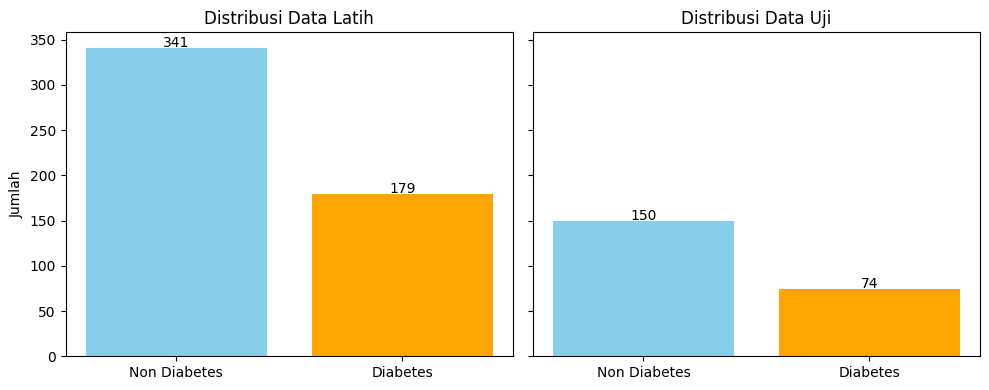

In [107]:
# distribusi kelas pada data latih dan data uji
train_y_counts = y_train.value_counts()
test_y_counts = y_test.value_counts()
test_counts  = y_test.value_counts().reindex([0, 1], fill_value=0)

labels = ["Non Diabetes", "Diabetes"]
x = [0, 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].bar(x, train_y_counts.values, color=["skyblue", "orange"])
axes[0].set_title("Distribusi Data Latih")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Jumlah")

axes[1].bar(x, test_counts.values, color=["skyblue", "orange"])
axes[1].set_title("Distribusi Data Uji")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)

# angka di atas bar (opsional tapi masih sederhana)
for ax, counts in zip(axes, [train_y_counts, test_counts]):
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(int(v)), ha="center")

plt.tight_layout()
plt.show()

### Balancing Data

In [108]:
# balancing dengan SMOTE
jumlah_per_kelas = y_train.value_counts()
jumlah_kelas_mayoritas = jumlah_per_kelas.max()
jumlah_kelas_minoritas = jumlah_per_kelas.min()
IR = jumlah_kelas_mayoritas / jumlah_kelas_minoritas
print(f"Imbalance Ratio: {IR}")

if IR > 1.5:
    pass
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
else:
    print("Data sudah cukup seimbang")

Imbalance Ratio: 1.905027932960894


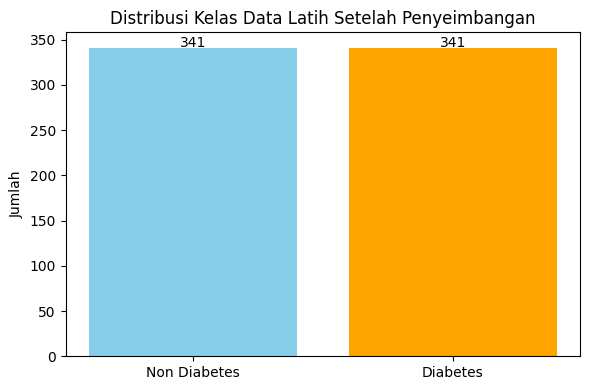

In [109]:
counts_smote =y_train_smote.value_counts()

plt.figure(figsize=(6, 4))
plt.bar([0, 1], counts_smote.values, color=["skyblue", "orange"])
plt.xticks([0, 1], ["Non Diabetes", "Diabetes"])
plt.ylabel("Jumlah")
plt.title("Distribusi Kelas Data Latih Setelah Penyeimbangan")

for i, v in enumerate(counts_smote.values):
    plt.text(i, v + 1, str(int(v)), ha="center")

plt.tight_layout()
plt.show()

## UJI COBA SKENARIO

---
# 🔵 SECTION A — PEMBAGIAN DATA 70:30

In [110]:
# Cross-validation dengan KFold
n_splits = 5
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
for split, (train_index, validasi_index) in enumerate(kfold.split(X_train_smote, y_train_smote), 1):
    print(f"split {split}:\n")
    print(f"Jumlah data train: {len(train_index)}")
    print(f"Jumlah data validation: {len(validasi_index)}\n")
    print(f"Train index: {', '.join(map(str, train_index))}")
    print(f"Validation index:  {', '.join(map(str, validasi_index))}\n")

split 1:

Jumlah data train: 545
Jumlah data validation: 137

Train index: 0, 1, 3, 4, 5, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 40, 42, 43, 45, 46, 47, 48, 50, 52, 53, 57, 58, 59, 61, 62, 64, 66, 67, 68, 71, 73, 74, 75, 79, 80, 83, 84, 85, 87, 88, 89, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 102, 103, 104, 105, 106, 107, 111, 112, 113, 114, 115, 116, 117, 119, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 134, 137, 138, 139, 140, 141, 142, 143, 144, 146, 147, 149, 150, 151, 152, 153, 154, 156, 157, 159, 160, 161, 162, 163, 166, 167, 168, 169, 170, 171, 172, 173, 175, 177, 178, 179, 180, 183, 184, 185, 186, 187, 188, 189, 190, 191, 193, 194, 195, 196, 197, 198, 200, 201, 202, 203, 205, 206, 207, 208, 214, 216, 217, 218, 219, 221, 222, 224, 225, 226, 228, 229, 230, 231, 232, 233, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 248, 249, 251, 252, 253, 254, 255, 256, 257, 258, 260, 261, 262, 263, 266, 2

In [111]:
def plot_confusion_matrix(nama_skenario, y_asli, y_prediksi):
    judul = nama_skenario
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_asli, y_prediksi)

    # Menambahkan annot_kws={"size": 16} untuk memperbesar angka di dalam kotak
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Non Diabetes", "Diabetes"],
                yticklabels=["Non Diabetes", "Diabetes"],
                annot_kws={"size": 18}) # <-- Angka 18 bisa kamu naik-turunkan sesuai selera

    # Memperbesar font judul dan label agar seimbang dengan angka di dalam
    ax.set_title(f"Confusion Matrix – {judul}", fontsize=14, pad=10)
    ax.set_xlabel("Prediksi", fontsize=12)
    ax.set_ylabel("Aktual", fontsize=12)

    # Memperbesar font label x dan y (Non Diabetes/Diabetes)
    ax.tick_params(axis='both', labelsize=11)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def evaluasi_testing(nama_skenario, y_asli, y_prediksi):
    judul = f"{nama_skenario}"
    akurasi = accuracy_score(y_asli, y_prediksi)
    presisi = precision_score(y_asli, y_prediksi, zero_division=0)
    recall  = recall_score(y_asli, y_prediksi, zero_division=0)
    f1      = f1_score(y_asli, y_prediksi, zero_division=0)
    print(f"  Hasil Evaluasi Testing – {judul}")
    print(f"  Akurasi  : {akurasi:.4f}")
    print(f"  Presisi  : {presisi:.4f}")
    print(f"  Recall   : {recall:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    return {
        "Model"   : judul,
        "Akurasi" : round(akurasi, 4),
        "Presisi" : round(presisi, 4),
        "Recall"  : round(recall,  4),
        "F1-Score": round(f1,      4),
    }


def tampilkan_tabel_perbandingan(y_pred, y_asli, nama_skenario="Skenario", jumlah=5):
    """
    Fungsi untuk menampilkan tabel perbandingan hasil prediksi model
    dengan diagnosis asli beserta keterangan klasifikasinya.
    """
    # 1. Pastikan pengambilan data aman (berlaku untuk Pandas Series maupun Numpy Array)
    y_test_sample = y_asli.iloc[:jumlah].values if hasattr(y_asli, 'iloc') else y_asli[:jumlah]
    y_pred_sample = y_pred[:jumlah]

    # 2. Logika Keterangan (TP, TN, FP, FN)
    keterangan = []
    for pred, asli in zip(y_pred_sample, y_test_sample):
        if pred == asli:
            if asli == 1:
                keterangan.append("Tebakan Benar (True Positive)")
            else:
                keterangan.append("Tebakan Benar (True Negative)")
        else:
            if pred == 1 and asli == 0:
                keterangan.append("Tebakan Salah (False Positive)")
            elif pred == 0 and asli == 1:
                keterangan.append("Tebakan Salah (False Negative)")

    # 3. Menyusun DataFrame
    df_perbandingan = pd.DataFrame({
        f'Prediksi {nama_skenario}(y_pred)': y_pred_sample,
        f'Label Aktual(y_test)': y_test_sample,
        'Keterangan': keterangan
    })

    # 4. Menampilkan tabel
    print(f"")
    display(df_perbandingan)

### Skenario 1 (KNN)

In [ ]:
estimators = [
    ("knn", knn_final),
    ("lr",  lr_final),
    ("svm", svm_final),
    ("ann", ann_final)
]

In [112]:
import time
_t0 = time.time()
param_grid_knn = {
    "n_neighbors": [5,7,9,11,13,15,19],
    "metric": ["euclidean", "manhattan"],
    "weights": ["uniform", "distance"],
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),param_grid_knn, cv=kfold,
    scoring="accuracy",n_jobs=-1,verbose=1,
)
grid_knn.fit(X_train_smote, y_train_smote)
print(f"KNN Best Score: {grid_knn.best_score_:.4f}")
print(f"KNN Best Params: {grid_knn.best_params_}")
results_knn = pd.DataFrame(grid_knn.cv_results_)
best_idx = grid_knn.best_index_
best_idx = grid_knn.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_knn.best_score_:.4f}")
waktu_train_knn = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_knn: {waktu_train_knn:.2f} ms")

Fitting 5 folds for each of 28 candidates, totalling 140 fits
KNN Best Score: 0.8020
KNN Best Params: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Fold 1: 0.8175
Fold 2: 0.8394
Fold 3: 0.7868
Fold 4: 0.7868
Fold 5: 0.7794
Mean: 0.8020
waktu_train_knn: 19618.47 ms


,Prediksi Skenario 1(y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


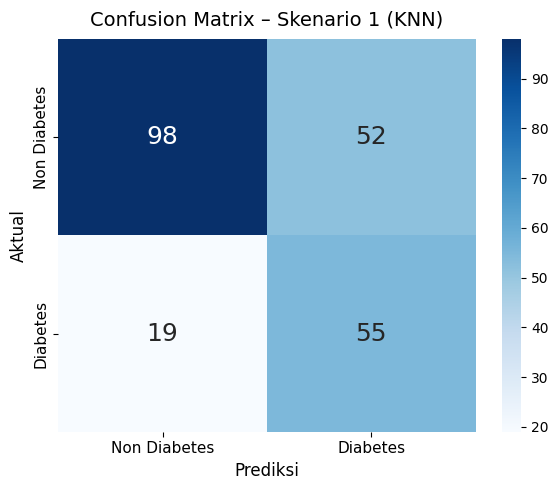

  Hasil Evaluasi Testing – Skenario 1 (KNN)
  Akurasi  : 0.6830
  Presisi  : 0.5140
  Recall   : 0.7432
  F1-Score : 0.6077
waktu_predict_knn: 19.56 ms


In [113]:
knn_final = grid_knn.best_estimator_
import time
_t0 = time.time()
y_pred_knn_final = knn_final.predict(X_test)
waktu_predict_knn = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_knn_final, y_test, nama_skenario="Skenario 1")
plot_confusion_matrix("Skenario 1 (KNN)", y_test, y_pred_knn_final)
hasil_knn_final = evaluasi_testing("Skenario 1 (KNN)", y_test, y_pred_knn_final)
print(f"waktu_predict_knn: {waktu_predict_knn:.2f} ms")

### Skenario 2 (LR)

In [114]:
import time
_t0 = time.time()
# membuat model Logistic Regression dengan GridSearchCV
param_grid_lr = {
    "C": np.logspace(-4, 4, 20),
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l1", "l2"],
}
grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),param_grid_lr,cv=kfold,
    scoring="accuracy",n_jobs=-1,verbose=1,
)
grid_lr.fit(X_train_smote, y_train_smote)
print(f"LR Best Score: {grid_lr.best_score_:.4f}")
print(f"LR Best Params: {grid_lr.best_params_}")
results_lr = pd.DataFrame(grid_lr.cv_results_)
best_idx = grid_lr.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_lr.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_lr.best_score_:.4f}")
waktu_train_lr = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_lr: {waktu_train_lr:.2f} ms")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LR Best Score: 0.7609
LR Best Params: {'C': np.float64(0.08858667904100823), 'penalty': 'l2', 'solver': 'liblinear'}
Fold 1: 0.7518
Fold 2: 0.8102
Fold 3: 0.7279
Fold 4: 0.7353
Fold 5: 0.7794
Mean: 0.7609
waktu_train_lr: 1552.21 ms


,Prediksi Skenario 2(y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


waktu_predict_lr: 6.30 ms


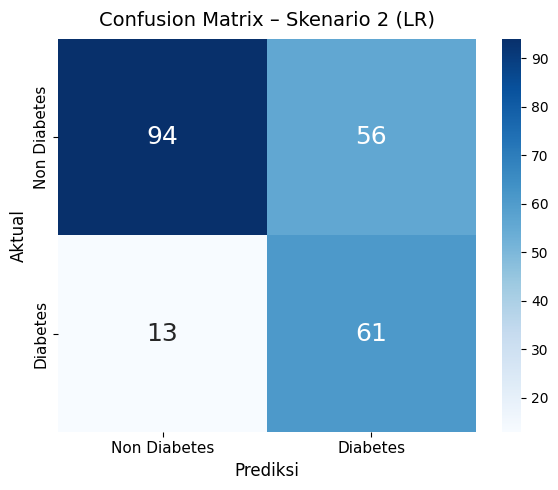

  Hasil Evaluasi Testing – Skenario 2 (LR)
  Akurasi  : 0.6920
  Presisi  : 0.5214
  Recall   : 0.8243
  F1-Score : 0.6387


In [115]:
lr_final = grid_lr.best_estimator_
import time
_t0 = time.time()
y_pred_lr_final = lr_final.predict(X_test)
waktu_predict_lr = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_lr_final, y_test, nama_skenario="Skenario 2")
print(f"waktu_predict_lr: {waktu_predict_lr:.2f} ms")
plot_confusion_matrix("Skenario 2 (LR)", y_test, y_pred_lr_final)
hasil_lr_final = evaluasi_testing("Skenario 2 (LR)", y_test, y_pred_lr_final)

### Skenario 3 (SVM)

In [116]:
import time
_t0 = time.time()
# membuat model SVM dengan GridSearchCV
param_grid_svm = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear"],
}
grid_svm = GridSearchCV(
    SVC(random_state=42, probability=True),param_grid_svm,cv=kfold,
    scoring="accuracy",n_jobs=-1,verbose=1,
)
grid_svm.fit(X_train_smote, y_train_smote)
print(f"SVM Best Score: {grid_svm.best_score_:.4f}")
print(f"SVM Best Params: {grid_svm.best_params_}")
results_svm = pd.DataFrame(grid_svm.cv_results_)
best_idx = grid_svm.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_svm.best_score_:.4f}")
waktu_train_svm = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_svm: {waktu_train_svm:.2f} ms")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Best Score: 0.7962
SVM Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Fold 1: 0.8102
Fold 2: 0.7883
Fold 3: 0.8015
Fold 4: 0.8015
Fold 5: 0.7794
Mean: 0.7962
waktu_train_svm: 9000.75 ms


,Prediksi Skenario 3(y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


waktu_predict_svm: 17.19 ms


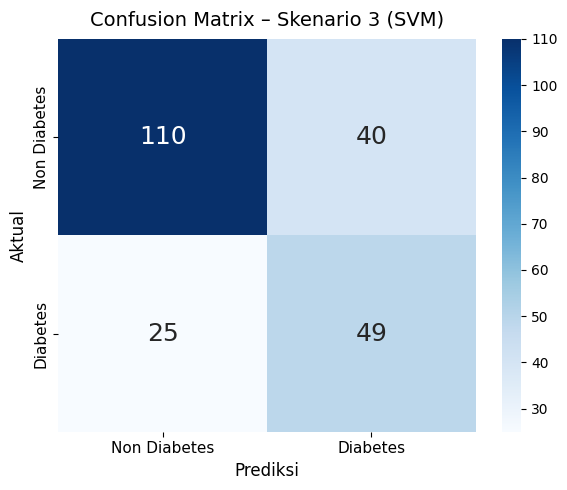

  Hasil Evaluasi Testing – Skenario 3 (SVM)
  Akurasi  : 0.7098
  Presisi  : 0.5506
  Recall   : 0.6622
  F1-Score : 0.6012


In [117]:
svm_final = grid_svm.best_estimator_
import time
_t0 = time.time()
y_pred_svm_final = svm_final.predict(X_test)
waktu_predict_svm = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_svm_final, y_test, nama_skenario="Skenario 3")
print(f"waktu_predict_svm: {waktu_predict_svm:.2f} ms")
plot_confusion_matrix("Skenario 3 (SVM)", y_test, y_pred_svm_final)
hasil_svm_final = evaluasi_testing("Skenario 3 (SVM)", y_test, y_pred_svm_final)

### Skenario 4 (ANN)

In [118]:
import time
_t0 = time.time()
# membuat model ann dengan GridSearchCV
param_grid_ann = {
    "max_iter": [100, 500, 1000],
    "hidden_layer_sizes": [(100,), (50, 50), (30, 20), (20, 10)],
    "activation": ["relu", "tanh", "logistic"],
    "learning_rate_init": [0.0001, 0.001],
}
grid_ann = GridSearchCV(
    MLPClassifier(random_state=42),param_grid_ann,cv=kfold,
    scoring="accuracy",n_jobs=-1,verbose=1,
)
grid_ann.fit(X_train_smote, y_train_smote)
print(f"ANN Best Score: {grid_ann.best_score_:.4f}")
print(f"ANN Best Params: {grid_ann.best_params_}")
results_ann = pd.DataFrame(grid_ann.cv_results_)
best_idx = grid_ann.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_ann.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_ann.best_score_:.4f}")
waktu_train_ann = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_ann: {waktu_train_ann:.2f} ms")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
ANN Best Score: 0.7991
ANN Best Params: {'activation': 'relu', 'hidden_layer_sizes': (30, 20), 'learning_rate_init': 0.001, 'max_iter': 1000}
Fold 1: 0.8102
Fold 2: 0.7810
Fold 3: 0.8529
Fold 4: 0.8015
Fold 5: 0.7500
Mean: 0.7991
waktu_train_ann: 134311.30 ms


,Prediksi Skenario 4(y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


waktu_predict_ann: 2.01 ms


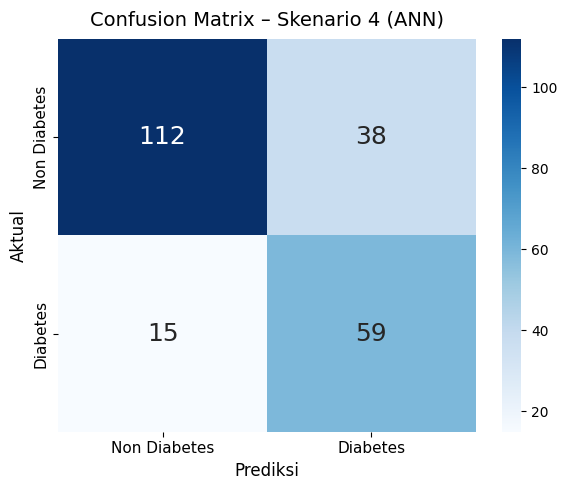

  Hasil Evaluasi Testing – Skenario 4 (ANN)
  Akurasi  : 0.7634
  Presisi  : 0.6082
  Recall   : 0.7973
  F1-Score : 0.6901


In [119]:
ann_final = grid_ann.best_estimator_
import time
_t0 = time.time()
y_pred_ann_final = ann_final.predict(X_test)
waktu_predict_ann = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_ann_final, y_test, nama_skenario="Skenario 4")
print(f"waktu_predict_ann: {waktu_predict_ann:.2f} ms")
plot_confusion_matrix("Skenario 4 (ANN)", y_test, y_pred_ann_final)
hasil_ann_final = evaluasi_testing("Skenario 4 (ANN)", y_test, y_pred_ann_final)

### MEMBUAT DATA TRAINING DAN TESTING UNTUK META LEARNER

In [ ]:
# import time
# _t0_meta_train = time.time()
# models = [
#     ("knn", knn_final),("lr",  lr_final),
#     ("svm", svm_final),("ann", ann_final),
# ]
# dataset_training_meta = []
# for train_idx, val_idx in kfold.split(X_train_smote, y_train_smote):
#     X_tr  = X_train_smote.iloc[train_idx]
#     y_tr  = y_train_smote.iloc[train_idx]
#     X_val = X_train_smote.iloc[val_idx]
#     fold_preds = []
#     for name, est in models:
#         model = clone(est)
#         model.fit(X_tr, y_tr)
#         proba = model.predict_proba(X_val)
#         fold_preds.append(pd.DataFrame(
#             proba,index=val_idx,columns=[f"{name}_prob_0", f"{name}_prob_1"]
#         ))
#     fold_df = pd.concat(fold_preds, axis=1)
#     dataset_training_meta.append(fold_df)
# df_fitur_meta = pd.concat(dataset_training_meta).sort_index()
# waktu_buat_dataset_training_meta = (time.time() - _t0_meta_train) * 1000  # ms
# print(f"waktu_buat_dataset_training_meta: {waktu_buat_dataset_training_meta:.2f} ms")

waktu_buat_dataset_training_meta: 9806.26 ms


In [ ]:
# # df_fitur_meta.to_excel("fitur_meta_training.xlsx", index=False)
# df_fitur_meta

,knn_prob_0,knn_prob_1,lr_prob_0,lr_prob_1,svm_prob_0,svm_prob_1,ann_prob_0,ann_prob_1
0,1.000000,0.000000,0.659610,0.340390,0.975672,0.024328,0.999996,0.000004
1,1.000000,0.000000,0.570351,0.429649,0.970102,0.029898,0.995882,0.004118
2,0.627988,0.372012,0.544594,0.455406,0.820038,0.179962,0.956311,0.043689
3,1.000000,0.000000,0.570651,0.429349,0.841913,0.158087,0.997406,0.002594
4,0.275446,0.724554,0.389719,0.610281,0.400960,0.599040,0.511387,0.488613
...,...,...,...,...,...,...,...,...
677,0.286950,0.713050,0.453227,0.546773,0.368950,0.631050,0.078343,0.921657
678,0.000000,1.000000,0.436375,0.563625,0.218962,0.781038,0.269260,0.730740
679,0.000000,1.000000,0.471163,0.528837,0.126149,0.873851,0.023632,0.976368
680,0.146442,0.853558,0.453838,0.546162,0.296759,0.703241,0.430946,0.569054


In [ ]:
# import time
# _t0_meta_test = time.time()
# dataset_testing_meta = []
# for name, est in models:
#     proba = est.predict_proba(X_test)
#     dataset_testing_meta.append(pd.DataFrame(
#         proba,
#         columns=[f"{name}_prob_0", f"{name}_prob_1"]
#     ))
# df_fitur_meta_uji = pd.concat(dataset_testing_meta, axis=1)
# waktu_buat_dataset_testing_meta = (time.time() - _t0_meta_test) * 1000  # ms
# print(f"waktu_buat_dataset_testing_meta: {waktu_buat_dataset_testing_meta:.2f} ms")

waktu_buat_dataset_testing_meta: 9.74 ms


In [ ]:
# # df_fitur_meta_uji.to_excel("fitur_meta_testing.xlsx", index=False)
# df_fitur_meta_uji

,knn_prob_0,knn_prob_1,lr_prob_0,lr_prob_1,svm_prob_0,svm_prob_1,ann_prob_0,ann_prob_1
0,0.187029,0.812971,0.373691,0.626309,0.248527,0.751473,0.192644,0.807356
1,1.000000,0.000000,0.620374,0.379626,0.903266,0.096734,0.754435,0.245565
2,1.000000,0.000000,0.503703,0.496297,0.795190,0.204810,0.767288,0.232712
3,0.830408,0.169592,0.569838,0.430162,0.882301,0.117699,0.914123,0.085877
4,1.000000,0.000000,0.656651,0.343349,0.951384,0.048616,0.997291,0.002709
...,...,...,...,...,...,...,...,...
219,0.232368,0.767632,0.286281,0.713719,0.527138,0.472862,0.064285,0.935715
220,0.195835,0.804165,0.381192,0.618808,0.225627,0.774373,0.235268,0.764732
221,0.827822,0.172178,0.511122,0.488878,0.605026,0.394974,0.466550,0.533450
222,0.409555,0.590445,0.381090,0.618910,0.272919,0.727081,0.186152,0.813848


In [ ]:
# X_meta_latih = df_fitur_meta
# y_meta_latih = y_train_smote
# X_meta_uji = df_fitur_meta_uji
# y_meta_uji = y_test

In [ ]:
# print((df_fitur_meta.index == y_train_smote.index).all()) ## ngecek apakah urutan index fitur meta latih sama dengan label latih

True


### Cek Korelasi Hasil Prediksi Base Learner

=== MATRIKS KORELASI ANTAR BASE LEARNER (OOF) [70:30] ===
        KNN      LR     SVM     ANN
KNN  1.0000  0.7412  0.8647  0.7989
LR   0.7412  1.0000  0.7478  0.7782
SVM  0.8647  0.7478  1.0000  0.8832
ANN  0.7989  0.7782  0.8832  1.0000


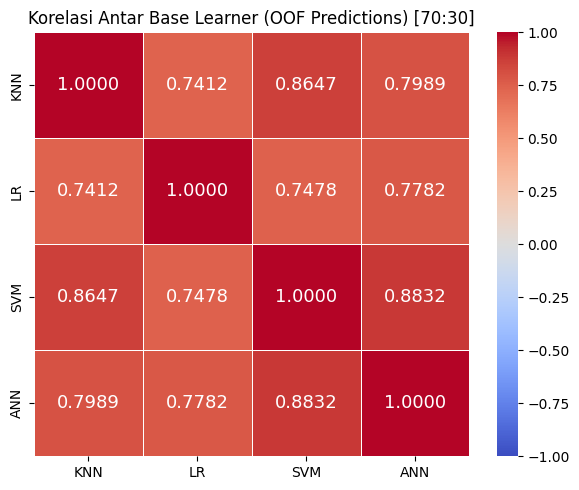


Interpretasi:
  KNN vs LR: r = 0.7412 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  KNN vs SVM: r = 0.8647 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  KNN vs ANN: r = 0.7989 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  LR vs SVM: r = 0.7478 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  LR vs ANN: r = 0.7782 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  SVM vs ANN: r = 0.8832 → 🔶 SEDANG — masih ada keberagaman, namun terbatas


In [ ]:
# # ============================================================
# # CEK KORELASI ANTAR BASE LEARNER
# # Menggunakan OOF (Out-of-Fold) predictions dari meta-training set
# # Korelasi dihitung dari prob_1 (probabilitas kelas positif) tiap base learner
# # Referensi: Dietterich (2000) — base learner sebaiknya tidak berkorelasi tinggi
# # agar meta-learner mendapat informasi yang beragam
# # ============================================================

# # Ambil hanya kolom prob_1 dari masing-masing base learner (OOF)
# df_oof_prob = df_fitur_meta[[
#     'knn_prob_1', 'lr_prob_1', 'svm_prob_1', 'ann_prob_1'
# ]].copy()
# df_oof_prob.columns = ['KNN', 'LR', 'SVM', 'ANN']

# # Hitung matriks korelasi
# corr_matrix = df_oof_prob.corr()
# print(f'=== MATRIKS KORELASI ANTAR BASE LEARNER (OOF) [70:30] ===')
# print(corr_matrix.round(4))

# # Visualisasi heatmap
# fig, ax = plt.subplots(figsize=(6, 5))
# sns.heatmap(
#     corr_matrix, annot=True, fmt='.4f', cmap='coolwarm',
#     vmin=-1, vmax=1, ax=ax, annot_kws={'size': 13},
#     linewidths=0.5
# )
# ax.set_title(f'Korelasi Antar Base Learner (OOF Predictions) [70:30]', fontsize=12)
# plt.tight_layout()
# plt.show()

# # Interpretasi otomatis
# print('\nInterpretasi:')
# pairs = [('KNN','LR'), ('KNN','SVM'), ('KNN','ANN'),
#          ('LR','SVM'),  ('LR','ANN'),  ('SVM','ANN')]
# for a, b in pairs:
#     r = corr_matrix.loc[a, b]
#     if abs(r) >= 0.9:
#         status = '⚠️  TINGGI — base learner terlalu mirip, stacking kurang optimal'
#     elif abs(r) >= 0.7:
#         status = '🔶 SEDANG — masih ada keberagaman, namun terbatas'
#     else:
#         status = '✅ RENDAH — base learner cukup beragam'
#     print(f'  {a} vs {b}: r = {r:.4f} → {status}')

In [ ]:
estimators = [
    ("knn", knn_final),
    ("lr",  lr_final),
    ("svm", svm_final),
    ("ann", ann_final)
]

### Skenario 5 Stacking (Meta-KNN)

In [ ]:
import time
_t0 = time.time()
stacking_knn = StackingClassifier(
    estimators=estimators,
    final_estimator=KNeighborsClassifier(),
    cv=kfold,
    stack_method='predict_proba',
    n_jobs=-1
)
grid_knn_meta = GridSearchCV(
    estimator=stacking_knn,
    param_grid=param_grid_knn,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_knn_meta.fit(X_train_smote, y_train_smote)
print(f"KNN Meta Best Score: {grid_knn_meta.best_score_:.4f}")
print(f"KNN Meta Best Params: {grid_knn_meta.best_params_}")
results_knn_meta = pd.DataFrame(grid_knn_meta.cv_results_)
best_idx = grid_knn_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_knn_meta.best_score_:.4f}")
waktu_train_knn_meta = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_knn_meta: {waktu_train_knn_meta:.2f} ms")

Fitting 5 folds for each of 28 candidates, totalling 140 fits
KNN Meta Best Score: 0.8269
KNN Meta Best Params: {'metric': 'euclidean', 'n_neighbors': 19, 'weights': 'uniform'}
Fold 1: 0.8540
Fold 2: 0.8321
Fold 3: 0.8456
Fold 4: 0.8309
Fold 5: 0.7721
Mean: 0.8269
waktu_train_knn_meta: 478.99 ms


,Prediksi Skenario 5 Stacking (Meta-KNN)(y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


waktu_predict_knn_meta: 33.51 ms


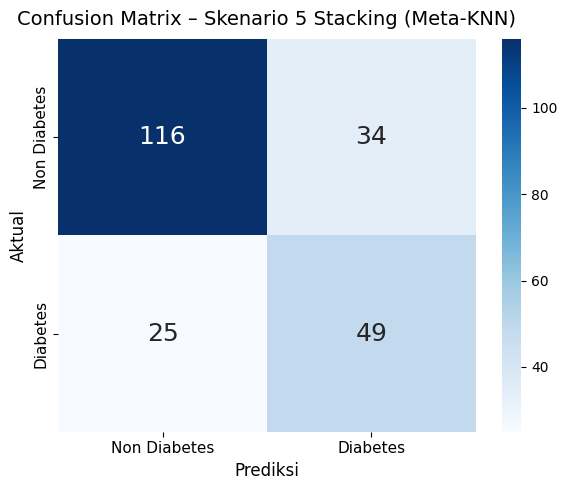

  Hasil Evaluasi Testing – Skenario 5 Stacking (Meta-KNN)
  Akurasi  : 0.7366
  Presisi  : 0.5904
  Recall   : 0.6622
  F1-Score : 0.6242


In [ ]:
knn_meta_final = grid_knn_meta.best_estimator_
import time
_t0 = time.time()
y_pred_knn_meta_final = knn_meta_final.predict(X_test)
waktu_predict_knn_meta = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_knn_meta_final, y_test, nama_skenario="Skenario 5 Stacking (Meta-KNN)")
print(f"waktu_predict_knn_meta: {waktu_predict_knn_meta:.2f} ms")
plot_confusion_matrix("Skenario 5 Stacking (Meta-KNN)", y_test, y_pred_knn_meta_final)
hasil_knn_meta_final = evaluasi_testing("Skenario 5 Stacking (Meta-KNN)", y_test, y_pred_knn_meta_final)

### Skenario 6 Stacking (Meta-LR)

In [ ]:
import time
_t0 = time.time()
# membuat model Logistic Regression Meta dengan GridSearchCV
stacking_lr = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42),
    cv=kfold,
    stack_method='predict',
    n_jobs=-1
)

grid_logreg_meta = GridSearchCV(
    estimator=stacking_lr,
    param_grid=param_grid_lr,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_logreg_meta.fit(X_train_smote, y_train_smote)
print(f"LogReg Meta Best Score: {grid_logreg_meta.best_score_:.4f}")
print(f"LogReg Meta Best Params: {grid_logreg_meta.best_params_}")
results_logreg_meta = pd.DataFrame(grid_logreg_meta.cv_results_)
best_idx = grid_logreg_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_logreg_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_logreg_meta.best_score_:.4f}")
waktu_train_lr_meta = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_lr_meta: {waktu_train_lr_meta:.2f} ms")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LogReg Meta Best Score: 0.8240
LogReg Meta Best Params: {'C': np.float64(0.23357214690901212), 'penalty': 'l2', 'solver': 'liblinear'}
Fold 1: 0.8467
Fold 2: 0.8394
Fold 3: 0.8382
Fold 4: 0.8162
Fold 5: 0.7794
Mean: 0.8240
waktu_train_lr_meta: 1243.69 ms


,Prediksi Skenario 6 Stacking (Meta-lr)(y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


waktu_predict_lr_meta: 2.01 ms


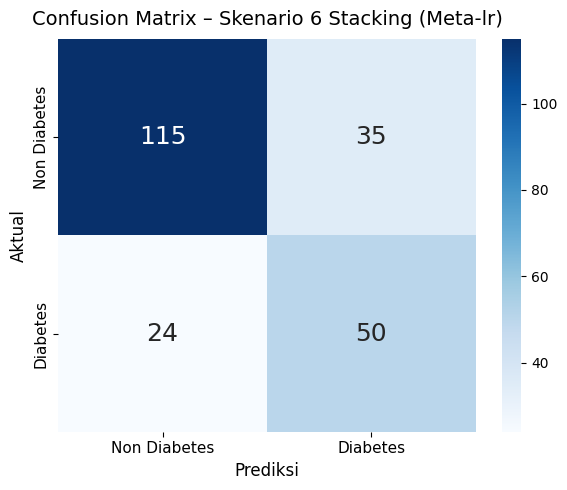

  Hasil Evaluasi Testing – Skenario 6 Stacking (Meta-lr)
  Akurasi  : 0.7366
  Presisi  : 0.5882
  Recall   : 0.6757
  F1-Score : 0.6289


In [ ]:
logreg_meta_final = grid_logreg_meta.best_estimator_
import time
_t0 = time.time()
y_pred_lr_meta_final = logreg_meta_final.predict(X_test)
waktu_predict_lr_meta = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_lr_meta_final, y_test, nama_skenario="Skenario 6 Stacking (Meta-lr)")
print(f"waktu_predict_lr_meta: {waktu_predict_lr_meta:.2f} ms")
plot_confusion_matrix("Skenario 6 Stacking (Meta-lr)", y_test, y_pred_lr_meta_final)
hasil_lr_meta_final = evaluasi_testing("Skenario 6 Stacking (Meta-lr)", y_test, y_pred_lr_meta_final)

### Skenario 7 Stacking (Meta-SVM)

In [ ]:
import time
_t0 = time.time()
# membuat model Support Vector Machine Meta dengan GridSearchCV
stacking_svm = StackingClassifier(
    estimators=estimators,
    final_estimator=SVC(random_state=42, probability=True),
    cv=kfold,
    stack_method='predict',
    n_jobs=-1
)

grid_svm_meta = GridSearchCV(
    estimator=stacking_svm,
    param_grid=param_grid_svm,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_svm_meta.fit(X_train_smote, y_train_smote)
print(f"SVM Meta Best Score: {grid_svm_meta.best_score_:.4f}")
print(f"SVM Meta Best Params: {grid_svm_meta.best_params_}")
results_svm_meta = pd.DataFrame(grid_svm_meta.cv_results_)
best_idx = grid_svm_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_svm_meta.best_score_:.4f}")
waktu_train_svm_meta = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_svm_meta: {waktu_train_svm_meta:.2f} ms")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Meta Best Score: 0.8240
SVM Meta Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Fold 1: 0.8540
Fold 2: 0.8394
Fold 3: 0.8382
Fold 4: 0.8162
Fold 5: 0.7721
Mean: 0.8240
waktu_train_svm_meta: 4370.39 ms


,Prediksi Skenario 7 Stacking (Meta-SVM)(y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


waktu_predict_svm_meta: 10.86 ms


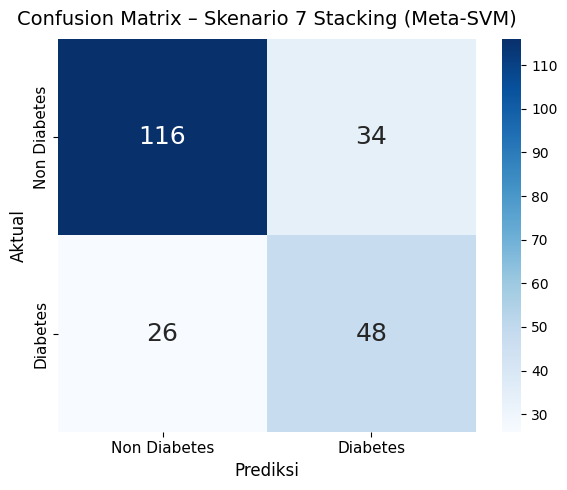

  Hasil Evaluasi Testing – Skenario 7 Stacking (Meta-SVM)
  Akurasi  : 0.7321
  Presisi  : 0.5854
  Recall   : 0.6486
  F1-Score : 0.6154


In [ ]:
svm_meta_final = grid_svm_meta.best_estimator_
import time
_t0 = time.time()
y_pred_svm_meta_final = svm_meta_final.predict(X_test)
waktu_predict_svm_meta = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_svm_meta_final, y_test, nama_skenario="Skenario 7 Stacking (Meta-SVM)")
print(f"waktu_predict_svm_meta: {waktu_predict_svm_meta:.2f} ms")
plot_confusion_matrix("Skenario 7 Stacking (Meta-SVM)", y_test, y_pred_svm_meta_final)
hasil_svm_meta_final = evaluasi_testing("Skenario 7 Stacking (Meta-SVM)", y_test, y_pred_svm_meta_final)

### Skenario 8 Stacking (Meta-ANN)

In [ ]:
import time
_t0 = time.time()
# membuat model ANN Meta dengan GridSearchCV
stacking_ann = StackingClassifier(
    estimators=estimators,
    final_estimator=MLPClassifier(random_state=42),
    cv=kfold,
    stack_method='predict',
    n_jobs=-1
)

grid_ann_meta = GridSearchCV(
    estimator=stacking_ann,
    param_grid=param_grid_ann,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_ann_meta.fit(X_train_smote, y_train_smote)
print(f"ANN Meta Best Score: {grid_ann_meta.best_score_:.4f}")
print(f"ANN Meta Best Params: {grid_ann_meta.best_params_}")
results_ann_meta = pd.DataFrame(grid_ann_meta.cv_results_)
best_idx = grid_ann_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_ann_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_ann_meta.best_score_:.4f}")
waktu_train_ann_meta = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_ann_meta: {waktu_train_ann_meta:.2f} ms")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
ANN Meta Best Score: 0.8269
ANN Meta Best Params: {'activation': 'tanh', 'hidden_layer_sizes': (20, 10), 'learning_rate_init': 0.0001, 'max_iter': 500}
Fold 1: 0.8467
Fold 2: 0.8394
Fold 3: 0.8382
Fold 4: 0.8162
Fold 5: 0.7941
Mean: 0.8269
waktu_train_ann_meta: 84543.72 ms


,Prediksi Skenario 8 Stacking (Meta-ANN)(y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


waktu_predict_ann_meta: 8.04 ms


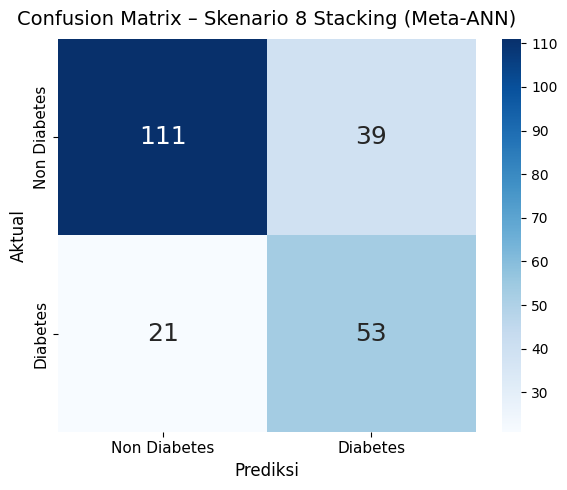

  Hasil Evaluasi Testing – Skenario 8 Stacking (Meta-ANN)
  Akurasi  : 0.7321
  Presisi  : 0.5761
  Recall   : 0.7162
  F1-Score : 0.6386


In [ ]:
ann_meta_final = grid_ann_meta.best_estimator_
import time
_t0 = time.time()
y_pred_ann_meta_final = ann_meta_final.predict(X_test)
waktu_predict_ann_meta = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_ann_meta_final, y_test, nama_skenario="Skenario 8 Stacking (Meta-ANN)")
print(f"waktu_predict_ann_meta: {waktu_predict_ann_meta:.2f} ms")
plot_confusion_matrix("Skenario 8 Stacking (Meta-ANN)", y_test, y_pred_ann_meta_final)
hasil_ann_meta_final = evaluasi_testing("Skenario 8 Stacking (Meta-ANN)", y_test, y_pred_ann_meta_final)

In [135]:
# === TABEL PERBANDINGAN SKENARIO 1-8 (SECTION A: 70:30) ===
hasil_semua_A = [
    hasil_knn_final,
    hasil_lr_final,
    hasil_svm_final,
    hasil_ann_final,
    hasil_knn_meta_final,
    hasil_lr_meta_final,
    hasil_svm_meta_final,
    hasil_ann_meta_final,
]

df_perbandingan_A = pd.DataFrame(hasil_semua_A)
df_perbandingan_A.insert(0, 'Pembagian Data', '70:30')
df_perbandingan_A.index = range(1, len(df_perbandingan_A) + 1)
df_perbandingan_A.index.name = 'No'
print('=== SECTION A (70:30) ===')
display(df_perbandingan_A)
print('\nModel Terbaik per Metrik (70:30):')
for metrik in ['Akurasi', 'Presisi', 'Recall', 'F1-Score']:
    best_idx = df_perbandingan_A[metrik].idxmax()
    best_model = df_perbandingan_A.loc[best_idx, 'Model']
    best_val   = df_perbandingan_A.loc[best_idx, metrik]
    print(f'  {metrik:10s}: {best_model} ({best_val:.4f})')

=== SECTION A (70:30) ===


,Pembagian Data,Model,Akurasi,Presisi,Recall,F1-Score
No,,,,,,
1,70:30,Skenario 1 (KNN),0.6830,0.5140,0.7432,0.6077
2,70:30,Skenario 2 (LR),0.6920,0.5214,0.8243,0.6387
3,70:30,Skenario 3 (SVM),0.7098,0.5506,0.6622,0.6012
4,70:30,Skenario 4 (ANN),0.7634,0.6082,0.7973,0.6901
5,70:30,Skenario 5 Stacking (Meta-KNN),0.7366,0.5904,0.6622,0.6242
6,70:30,Skenario 6 Stacking (Meta-lr),0.7366,0.5882,0.6757,0.6289
7,70:30,Skenario 7 Stacking (Meta-SVM),0.7321,0.5854,0.6486,0.6154
8,70:30,Skenario 8 Stacking (Meta-ANN),0.7321,0.5761,0.7162,0.6386



Model Terbaik per Metrik (70:30):
  Akurasi   : Skenario 4 (ANN) (0.7634)
  Presisi   : Skenario 4 (ANN) (0.6082)
  Recall    : Skenario 2 (LR) (0.8243)
  F1-Score  : Skenario 4 (ANN) (0.6901)


---
# 🟠 SECTION B — PEMBAGIAN DATA 80:20

Seluruh skenario 1–8 diulang menggunakan rasio split **80:20** (test_size=0.2).
Preprocessing (duplikat, imputasi, outlier, normalisasi) tetap sama — hanya split data yang berbeda.

In [136]:
# ============================================================
# SECTION B: SPLIT DATA 80:20
# ============================================================
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_ternormalisasi, y, test_size=0.2, random_state=42
)
print(f'[80:20] Jumlah data train : {len(X_train_B)}')
print(f'[80:20] Jumlah data test  : {len(X_test_B)}')

[80:20] Jumlah data train : 595
[80:20] Jumlah data test  : 149


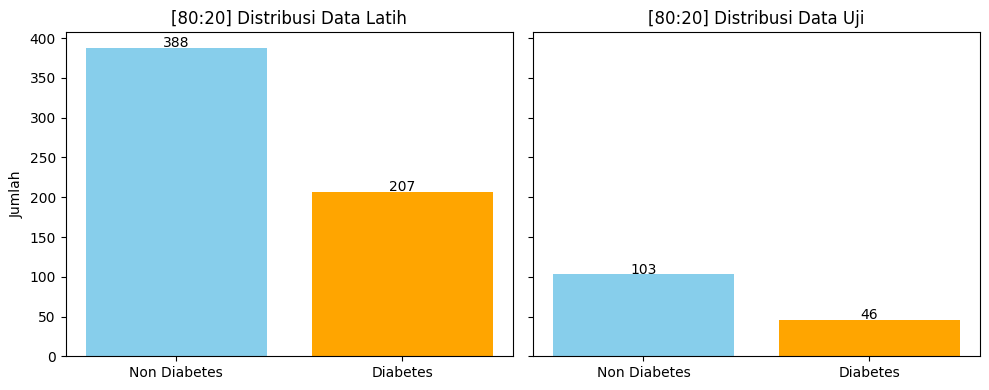

In [137]:
train_y_counts_B = y_train_B.value_counts()
test_counts_B = y_test_B.value_counts().reindex([0, 1], fill_value=0)

labels = ['Non Diabetes', 'Diabetes']
x = [0, 1]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].bar(x, train_y_counts_B.values, color=['skyblue', 'orange'])
axes[0].set_title('[80:20] Distribusi Data Latih')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels); axes[0].set_ylabel('Jumlah')
axes[1].bar(x, test_counts_B.values, color=['skyblue', 'orange'])
axes[1].set_title('[80:20] Distribusi Data Uji')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
for ax, counts in zip(axes, [train_y_counts_B, test_counts_B]):
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(int(v)), ha='center')
plt.tight_layout(); plt.show()

### Balancing Data (80:20)

[80:20] Imbalance Ratio: 1.8743961352657006


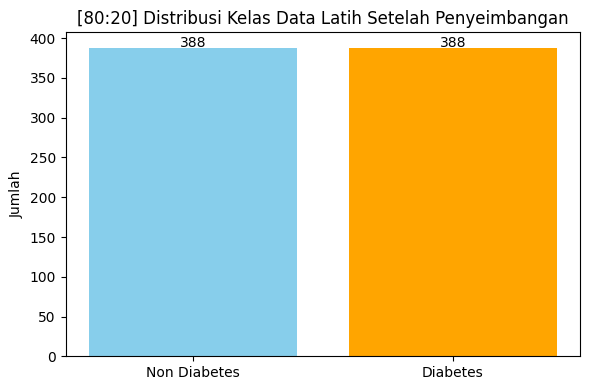

In [138]:
jumlah_per_kelas_B = y_train_B.value_counts()
IR_B = jumlah_per_kelas_B.max() / jumlah_per_kelas_B.min()
print(f'[80:20] Imbalance Ratio: {IR_B}')
if IR_B > 1.5:
    smote_B = SMOTE(random_state=42)
    X_train_smote_B, y_train_smote_B = smote_B.fit_resample(X_train_B, y_train_B)
else:
    X_train_smote_B, y_train_smote_B = X_train_B.copy(), y_train_B.copy()
    print('Data sudah cukup seimbang')

counts_smote_B = y_train_smote_B.value_counts()
plt.figure(figsize=(6, 4))
plt.bar([0, 1], counts_smote_B.values, color=['skyblue', 'orange'])
plt.xticks([0, 1], ['Non Diabetes', 'Diabetes'])
plt.ylabel('Jumlah')
plt.title('[80:20] Distribusi Kelas Data Latih Setelah Penyeimbangan')
for i, v in enumerate(counts_smote_B.values):
    plt.text(i, v + 1, str(int(v)), ha='center')
plt.tight_layout(); plt.show()

## UJI COBA SKENARIO (80:20)

In [139]:
kfold_B = KFold(n_splits=5, shuffle=True, random_state=42)

### Skenario 1 (KNN) [80:20]

In [ ]:
import time
_t0 = time.time()
grid_knn_B = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=kfold_B, scoring='accuracy', n_jobs=-1, verbose=1,
)
grid_knn_B.fit(X_train_smote_B, y_train_smote_B)
print(f'KNN Best Score (80:20): {grid_knn_B.best_score_:.4f}')
print(f'KNN Best Params: {grid_knn_B.best_params_}')
results_knn_B = pd.DataFrame(grid_knn_B.cv_results_)
best_idx = grid_knn_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_knn_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_knn_B.best_score_:.4f}')
waktu_train_knn_B = (time.time() - _t0) * 1000
print(f'waktu_train_knn_B: {waktu_train_knn_B:.2f} ms')

Fitting 5 folds for each of 28 candidates, totalling 140 fits
KNN Best Score (80:20): 0.7952
KNN Best Params: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}
Fold 1: 0.7436
Fold 2: 0.8000
Fold 3: 0.7871
Fold 4: 0.7742
Fold 5: 0.8710
Mean: 0.7952
waktu_train_knn_B: 942.21 ms


,Prediksi Skenario 1 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


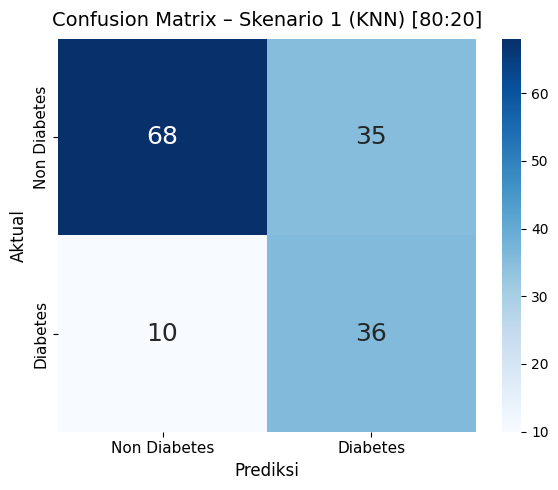

  Hasil Evaluasi Testing – Skenario 1 (KNN) [80:20]
  Akurasi  : 0.6980
  Presisi  : 0.5070
  Recall   : 0.7826
  F1-Score : 0.6154
waktu_predict_knn_B: 20.17 ms


In [141]:
knn_final_B = grid_knn_B.best_estimator_
import time
_t0 = time.time()
y_pred_knn_B = knn_final_B.predict(X_test_B)
waktu_predict_knn_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_knn_B, y_test_B, nama_skenario='Skenario 1 [80:20]')
plot_confusion_matrix('Skenario 1 (KNN) [80:20]', y_test_B, y_pred_knn_B)
hasil_knn_B = evaluasi_testing('Skenario 1 (KNN) [80:20]', y_test_B, y_pred_knn_B)
print(f'waktu_predict_knn_B: {waktu_predict_knn_B:.2f} ms')

### Skenario 2 (LR) [80:20]

In [142]:
import time
_t0 = time.time()
grid_lr_B = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=kfold_B, scoring='accuracy', n_jobs=-1, verbose=1,
)
grid_lr_B.fit(X_train_smote_B, y_train_smote_B)
print(f'LR Best Score (80:20): {grid_lr_B.best_score_:.4f}')
print(f'LR Best Params: {grid_lr_B.best_params_}')
results_lr_B = pd.DataFrame(grid_lr_B.cv_results_)
best_idx = grid_lr_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_lr_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_lr_B.best_score_:.4f}')
waktu_train_lr_B = (time.time() - _t0) * 1000
print(f'waktu_train_lr_B: {waktu_train_lr_B:.2f} ms')

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LR Best Score (80:20): 0.7604
LR Best Params: {'C': np.float64(1.623776739188721), 'penalty': 'l2', 'solver': 'liblinear'}
Fold 1: 0.6667
Fold 2: 0.8258
Fold 3: 0.7484
Fold 4: 0.7484
Fold 5: 0.8129
Mean: 0.7604
waktu_train_lr_B: 2115.23 ms


,Prediksi Skenario 2 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


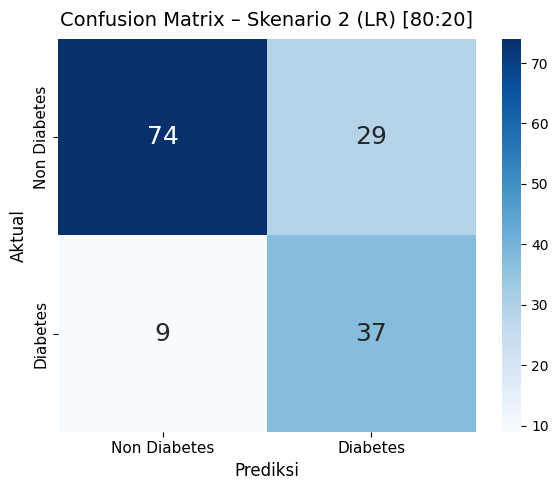

  Hasil Evaluasi Testing – Skenario 2 (LR) [80:20]
  Akurasi  : 0.7450
  Presisi  : 0.5606
  Recall   : 0.8043
  F1-Score : 0.6607
waktu_predict_lr_B: 0.00 ms


In [143]:
lr_final_B = grid_lr_B.best_estimator_
import time
_t0 = time.time()
y_pred_lr_B = lr_final_B.predict(X_test_B)
waktu_predict_lr_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_lr_B, y_test_B, nama_skenario='Skenario 2 [80:20]')
plot_confusion_matrix('Skenario 2 (LR) [80:20]', y_test_B, y_pred_lr_B)
hasil_lr_B = evaluasi_testing('Skenario 2 (LR) [80:20]', y_test_B, y_pred_lr_B)
print(f'waktu_predict_lr_B: {waktu_predict_lr_B:.2f} ms')

### Skenario 3 (SVM) [80:20]

In [144]:
import time
_t0 = time.time()
grid_svm_B = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm,
    cv=kfold_B, scoring='accuracy', n_jobs=-1, verbose=1,
)
grid_svm_B.fit(X_train_smote_B, y_train_smote_B)
print(f'SVM Best Score (80:20): {grid_svm_B.best_score_:.4f}')
print(f'SVM Best Params: {grid_svm_B.best_params_}')
results_svm_B = pd.DataFrame(grid_svm_B.cv_results_)
best_idx = grid_svm_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_svm_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_svm_B.best_score_:.4f}')
waktu_train_svm_B = (time.time() - _t0) * 1000
print(f'waktu_train_svm_B: {waktu_train_svm_B:.2f} ms')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Best Score (80:20): 0.7990
SVM Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Fold 1: 0.7628
Fold 2: 0.7935
Fold 3: 0.7742
Fold 4: 0.8000
Fold 5: 0.8645
Mean: 0.7990
waktu_train_svm_B: 8333.82 ms


,Prediksi Skenario 3 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


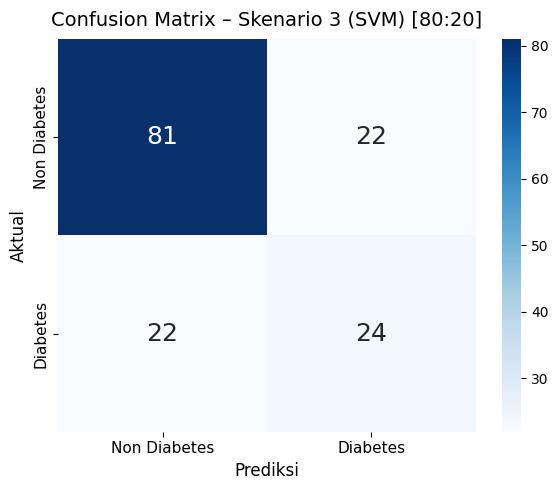

  Hasil Evaluasi Testing – Skenario 3 (SVM) [80:20]
  Akurasi  : 0.7047
  Presisi  : 0.5217
  Recall   : 0.5217
  F1-Score : 0.5217
waktu_predict_svm_B: 15.32 ms


In [145]:
svm_final_B = grid_svm_B.best_estimator_
import time
_t0 = time.time()
y_pred_svm_B = svm_final_B.predict(X_test_B)
waktu_predict_svm_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_svm_B, y_test_B, nama_skenario='Skenario 3 [80:20]')
plot_confusion_matrix('Skenario 3 (SVM) [80:20]', y_test_B, y_pred_svm_B)
hasil_svm_B = evaluasi_testing('Skenario 3 (SVM) [80:20]', y_test_B, y_pred_svm_B)
print(f'waktu_predict_svm_B: {waktu_predict_svm_B:.2f} ms')

### Skenario 4 (ANN) [80:20]

In [146]:
import time
_t0 = time.time()
grid_ann_B = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid_ann,
    cv=kfold_B, scoring='accuracy', n_jobs=-1, verbose=1,
)
grid_ann_B.fit(X_train_smote_B, y_train_smote_B)
print(f'ANN Best Score (80:20): {grid_ann_B.best_score_:.4f}')
print(f'ANN Best Params: {grid_ann_B.best_params_}')
results_ann_B = pd.DataFrame(grid_ann_B.cv_results_)
best_idx = grid_ann_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_ann_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_ann_B.best_score_:.4f}')
waktu_train_ann_B = (time.time() - _t0) * 1000
print(f'waktu_train_ann_B: {waktu_train_ann_B:.2f} ms')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
ANN Best Score (80:20): 0.7823
ANN Best Params: {'activation': 'relu', 'hidden_layer_sizes': (30, 20), 'learning_rate_init': 0.001, 'max_iter': 1000}
Fold 1: 0.7115
Fold 2: 0.8129
Fold 3: 0.7871
Fold 4: 0.7806
Fold 5: 0.8194
Mean: 0.7823
waktu_train_ann_B: 180035.69 ms


,Prediksi Skenario 4 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


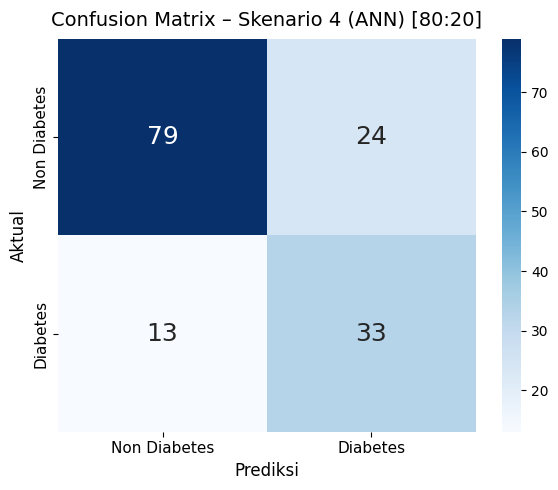

  Hasil Evaluasi Testing – Skenario 4 (ANN) [80:20]
  Akurasi  : 0.7517
  Presisi  : 0.5789
  Recall   : 0.7174
  F1-Score : 0.6408
waktu_predict_ann_B: 5.81 ms


In [147]:
ann_final_B = grid_ann_B.best_estimator_
import time
_t0 = time.time()
y_pred_ann_B = ann_final_B.predict(X_test_B)
waktu_predict_ann_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_ann_B, y_test_B, nama_skenario='Skenario 4 [80:20]')
plot_confusion_matrix('Skenario 4 (ANN) [80:20]', y_test_B, y_pred_ann_B)
hasil_ann_B = evaluasi_testing('Skenario 4 (ANN) [80:20]', y_test_B, y_pred_ann_B)
print(f'waktu_predict_ann_B: {waktu_predict_ann_B:.2f} ms')

### MEMBUAT DATA TRAINING DAN TESTING UNTUK META LEARNER [80:20]

In [ ]:
# import time
# _t0_meta_train_B = time.time()
# models_B = [
#     ('knn', knn_final_B), ('lr', lr_final_B),
#     ('svm', svm_final_B), ('ann', ann_final_B),
# ]
# dataset_training_meta_B = []
# for train_idx, val_idx in kfold_B.split(X_train_smote_B, y_train_smote_B):
#     X_tr  = X_train_smote_B.iloc[train_idx]
#     y_tr  = y_train_smote_B.iloc[train_idx]
#     X_val = X_train_smote_B.iloc[val_idx]
#     fold_preds = []
#     for name, est in models_B:
#         model = clone(est)
#         model.fit(X_tr, y_tr)
#         proba = model.predict_proba(X_val)
#         fold_preds.append(pd.DataFrame(
#             proba, index=val_idx, columns=[f'{name}_prob_0', f'{name}_prob_1']
#         ))
#     fold_df = pd.concat(fold_preds, axis=1)
#     dataset_training_meta_B.append(fold_df)
# df_fitur_meta_B = pd.concat(dataset_training_meta_B).sort_index()
# waktu_buat_dataset_training_meta_B = (time.time() - _t0_meta_train_B) * 1000
# print(f'waktu_buat_dataset_training_meta_B: {waktu_buat_dataset_training_meta_B:.2f} ms')
# df_fitur_meta_B

waktu_buat_dataset_training_meta_B: 17199.75 ms


,knn_prob_0,knn_prob_1,lr_prob_0,lr_prob_1,svm_prob_0,svm_prob_1,ann_prob_0,ann_prob_1
0,0.683944,0.316056,0.700179,0.299821,0.810402,0.189598,0.768583,0.231417
1,0.796230,0.203770,0.806809,0.193191,0.888702,0.111298,0.963317,0.036683
2,0.393627,0.606373,0.441144,0.558856,0.390740,0.609260,0.327316,0.672684
3,0.471754,0.528246,0.589460,0.410540,0.262967,0.737033,0.369264,0.630736
4,0.542870,0.457130,0.377494,0.622506,0.616995,0.383005,0.302957,0.697043
...,...,...,...,...,...,...,...,...
771,0.301388,0.698612,0.105494,0.894506,0.412763,0.587237,0.078224,0.921776
772,0.063949,0.936051,0.681546,0.318454,0.327827,0.672173,0.512566,0.487434
773,0.150533,0.849467,0.106670,0.893330,0.144215,0.855785,0.115156,0.884844
774,0.332384,0.667616,0.498302,0.501698,0.377940,0.622060,0.409084,0.590916


In [ ]:
# import time
# _t0_meta_test_B = time.time()
# dataset_testing_meta_B = []
# for name, est in models_B:
#     proba = est.predict_proba(X_test_B)
#     dataset_testing_meta_B.append(pd.DataFrame(
#         proba, columns=[f'{name}_prob_0', f'{name}_prob_1']
#     ))
# df_fitur_meta_uji_B = pd.concat(dataset_testing_meta_B, axis=1)
# waktu_buat_dataset_testing_meta_B = (time.time() - _t0_meta_test_B) * 1000
# print(f'waktu_buat_dataset_testing_meta_B: {waktu_buat_dataset_testing_meta_B:.2f} ms')
# df_fitur_meta_uji_B

waktu_buat_dataset_testing_meta_B: 62.85 ms


,knn_prob_0,knn_prob_1,lr_prob_0,lr_prob_1,svm_prob_0,svm_prob_1,ann_prob_0,ann_prob_1
0,0.473208,0.526792,0.325103,0.674897,0.314739,0.685261,0.226926,0.773074
1,1.000000,0.000000,0.704491,0.295509,0.927081,0.072919,0.800412,0.199588
2,0.741203,0.258797,0.627988,0.372012,0.824386,0.175614,0.687129,0.312871
3,0.934195,0.065805,0.708831,0.291169,0.943839,0.056161,0.962255,0.037745
4,1.000000,0.000000,0.892142,0.107858,0.951798,0.048202,0.991839,0.008161
...,...,...,...,...,...,...,...,...
144,0.300154,0.699846,0.213615,0.786385,0.096965,0.903035,0.113158,0.886842
145,0.414100,0.585900,0.562520,0.437480,0.557706,0.442294,0.395929,0.604071
146,0.128006,0.871994,0.470530,0.529470,0.210902,0.789098,0.416515,0.583485
147,0.000000,1.000000,0.245839,0.754161,0.088437,0.911563,0.048410,0.951590


In [ ]:
# X_meta_latih_B = df_fitur_meta_B
# y_meta_latih_B = y_train_smote_B
# X_meta_uji_B   = df_fitur_meta_uji_B
# y_meta_uji_B   = y_test_B
# print((df_fitur_meta_B.index == y_train_smote_B.index).all())

True


### Cek Korelasi Base Learner

=== MATRIKS KORELASI ANTAR BASE LEARNER (OOF) [80:20] ===
        KNN      LR     SVM     ANN
KNN  1.0000  0.8295  0.8698  0.8634
LR   0.8295  1.0000  0.7692  0.9131
SVM  0.8698  0.7692  1.0000  0.8707
ANN  0.8634  0.9131  0.8707  1.0000


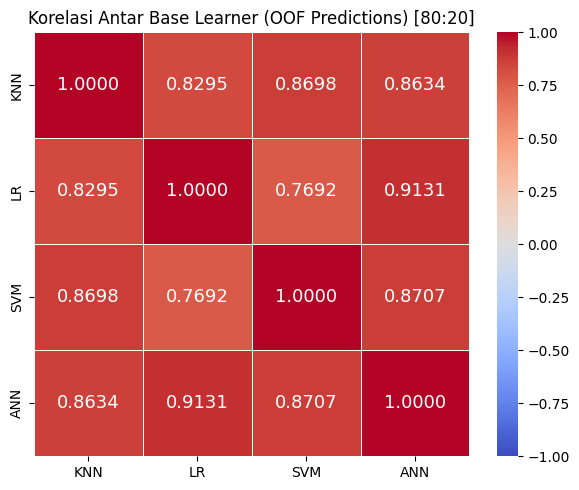


Interpretasi:
  KNN vs LR: r = 0.8295 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  KNN vs SVM: r = 0.8698 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  KNN vs ANN: r = 0.8634 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  LR vs SVM: r = 0.7692 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  LR vs ANN: r = 0.9131 → ⚠️  TINGGI — base learner terlalu mirip, stacking kurang optimal
  SVM vs ANN: r = 0.8707 → 🔶 SEDANG — masih ada keberagaman, namun terbatas


In [ ]:
# # ============================================================
# # CEK KORELASI ANTAR BASE LEARNER
# # Menggunakan OOF (Out-of-Fold) predictions dari meta-training set
# # Korelasi dihitung dari prob_1 (probabilitas kelas positif) tiap base learner
# # Referensi: Dietterich (2000) — base learner sebaiknya tidak berkorelasi tinggi
# # agar meta-learner mendapat informasi yang beragam
# # ============================================================

# # Ambil hanya kolom prob_1 dari masing-masing base learner (OOF)
# df_oof_prob_B = df_fitur_meta_B[[
#     'knn_prob_1', 'lr_prob_1', 'svm_prob_1', 'ann_prob_1'
# ]].copy()
# df_oof_prob_B.columns = ['KNN', 'LR', 'SVM', 'ANN']

# # Hitung matriks korelasi
# corr_matrix_B = df_oof_prob_B.corr()
# print(f'=== MATRIKS KORELASI ANTAR BASE LEARNER (OOF) [80:20] ===')
# print(corr_matrix_B.round(4))

# # Visualisasi heatmap
# fig, ax = plt.subplots(figsize=(6, 5))
# sns.heatmap(
#     corr_matrix_B, annot=True, fmt='.4f', cmap='coolwarm',
#     vmin=-1, vmax=1, ax=ax, annot_kws={'size': 13},
#     linewidths=0.5
# )
# ax.set_title(f'Korelasi Antar Base Learner (OOF Predictions) [80:20]', fontsize=12)
# plt.tight_layout()
# plt.show()

# # Interpretasi otomatis
# print('\nInterpretasi:')
# pairs = [('KNN','LR'), ('KNN','SVM'), ('KNN','ANN'),
#          ('LR','SVM'),  ('LR','ANN'),  ('SVM','ANN')]
# for a, b in pairs:
#     r = corr_matrix_B.loc[a, b]
#     if abs(r) >= 0.9:
#         status = '⚠️  TINGGI — base learner terlalu mirip, stacking kurang optimal'
#     elif abs(r) >= 0.7:
#         status = '🔶 SEDANG — masih ada keberagaman, namun terbatas'
#     else:
#         status = '✅ RENDAH — base learner cukup beragam'
#     print(f'  {a} vs {b}: r = {r:.4f} → {status}')

In [ ]:
estimators_B = [
    ('knn', knn_final_B),
    ('lr', lr_final_B),
    ('svm', svm_final_B),
    ('ann', ann_final_B)
]

### Skenario 5 Stacking (Meta-KNN) [80:20]

In [ ]:
import time
_t0 = time.time()
stacking_knn_B = StackingClassifier(
    estimators=estimators_B,
    final_estimator=KNeighborsClassifier(),
    cv=kfold_B,
    stack_method='predict_proba',
    n_jobs=-1
)
grid_knn_meta_B = GridSearchCV(
    estimator=stacking_knn_B,
    param_grid=param_grid_knn,
    cv=kfold_B,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
)
grid_knn_meta_B.fit(X_train_smote_B, y_train_smote_B)
print(f'KNN Meta Best Score (80:20): {grid_knn_meta_B.best_score_:.4f}')
print(f'KNN Meta Best Params: {grid_knn_meta_B.best_params_}')
results_knn_meta_B = pd.DataFrame(grid_knn_meta_B.cv_results_)
best_idx = grid_knn_meta_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_knn_meta_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_knn_meta_B.best_score_:.4f}')
waktu_train_knn_meta_B = (time.time() - _t0) * 1000
print(f'waktu_train_knn_meta_B: {waktu_train_knn_meta_B:.2f} ms')

Fitting 5 folds for each of 28 candidates, totalling 140 fits
KNN Meta Best Score (80:20): 0.8016
KNN Meta Best Params: {'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'uniform'}
Fold 1: 0.7564
Fold 2: 0.8194
Fold 3: 0.7742
Fold 4: 0.7935
Fold 5: 0.8645
Mean: 0.8016
waktu_train_knn_meta_B: 1054.59 ms


,Prediksi Skenario 5 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


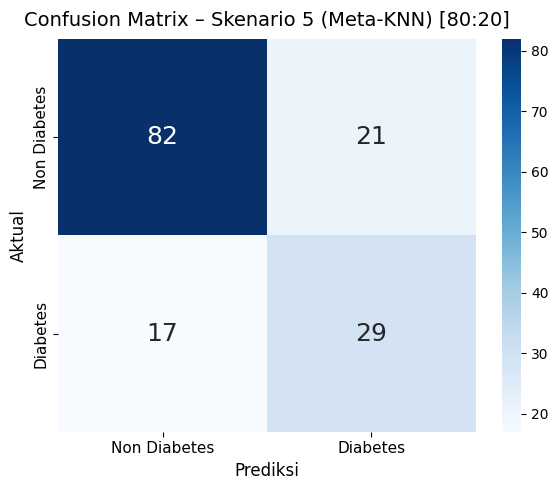

  Hasil Evaluasi Testing – Skenario 5 (Meta-KNN) [80:20]
  Akurasi  : 0.7450
  Presisi  : 0.5800
  Recall   : 0.6304
  F1-Score : 0.6042
waktu_predict_knn_meta_B: 22.55 ms


In [ ]:
knn_meta_final_B = grid_knn_meta_B.best_estimator_
import time
_t0 = time.time()
y_pred_knn_meta_B = knn_meta_final_B.predict(X_test_B)
waktu_predict_knn_meta_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_knn_meta_B, y_test_B, nama_skenario='Skenario 5 [80:20]')
plot_confusion_matrix('Skenario 5 (Meta-KNN) [80:20]', y_test_B, y_pred_knn_meta_B)
hasil_knn_meta_B = evaluasi_testing('Skenario 5 (Meta-KNN) [80:20]', y_test_B, y_pred_knn_meta_B)
print(f'waktu_predict_knn_meta_B: {waktu_predict_knn_meta_B:.2f} ms')

### Skenario 6 Stacking (Meta-LR) [80:20]

In [ ]:
import time
_t0 = time.time()

stacking_logreg_B = StackingClassifier(
    estimators=estimators_B,
    final_estimator=LogisticRegression(random_state=42),
    cv=kfold_B,
    stack_method='predict_proba',
    n_jobs=-1
)
grid_logreg_meta_B = GridSearchCV(
    estimator=stacking_logreg_B,
    param_grid=param_grid_lr,
    cv=kfold_B,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
)

grid_logreg_meta_B.fit(X_train_smote_B, y_train_smote_B)
print(f'LR Meta Best Score (80:20): {grid_logreg_meta_B.best_score_:.4f}')
print(f'LR Meta Best Params: {grid_logreg_meta_B.best_params_}')
results_logreg_meta_B = pd.DataFrame(grid_logreg_meta_B.cv_results_)
best_idx = grid_logreg_meta_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_logreg_meta_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_logreg_meta_B.best_score_:.4f}')
waktu_train_logreg_meta_B = (time.time() - _t0) * 1000
print(f'waktu_train_logreg_meta_B: {waktu_train_logreg_meta_B:.2f} ms')

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LR Meta Best Score (80:20): 0.8003
LR Meta Best Params: {'C': np.float64(0.23357214690901212), 'penalty': 'l1', 'solver': 'liblinear'}
Fold 1: 0.7692
Fold 2: 0.8194
Fold 3: 0.7935
Fold 4: 0.7742
Fold 5: 0.8452
Mean: 0.8003
waktu_train_logreg_meta_B: 2720.53 ms


,Prediksi Skenario 6 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


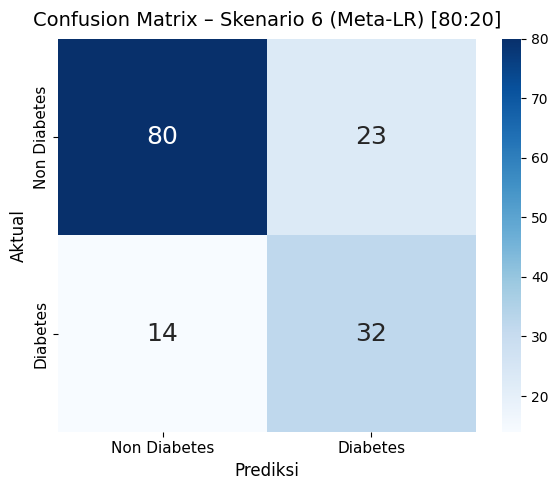

  Hasil Evaluasi Testing – Skenario 6 (Meta-LR) [80:20]
  Akurasi  : 0.7517
  Presisi  : 0.5818
  Recall   : 0.6957
  F1-Score : 0.6337
waktu_predict_lr_meta_B: 9.92 ms


In [ ]:
logreg_meta_final_B = grid_logreg_meta_B.best_estimator_
import time
_t0 = time.time()
y_pred_lr_meta_B = logreg_meta_final_B.predict(X_test_B)
waktu_predict_lr_meta_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_lr_meta_B, y_test_B, nama_skenario='Skenario 6 [80:20]')
plot_confusion_matrix('Skenario 6 (Meta-LR) [80:20]', y_test_B, y_pred_lr_meta_B)
hasil_lr_meta_B = evaluasi_testing('Skenario 6 (Meta-LR) [80:20]', y_test_B, y_pred_lr_meta_B)
print(f'waktu_predict_lr_meta_B: {waktu_predict_lr_meta_B:.2f} ms')

### Skenario 7 Stacking (Meta-SVM) [80:20]

In [ ]:
import time
_t0 = time.time()
stacking_svm_B = StackingClassifier(
    estimators=estimators_B,
    final_estimator=SVC(random_state=42, probability=True),
    cv=kfold_B,
    stack_method='predict_proba',
    n_jobs=-1,
    verbose=1
)
grid_svm_meta_B = GridSearchCV(
    estimator=stacking_svm_B,
    param_grid=param_grid_svm,
    cv=kfold_B,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_svm_meta_B.fit(X_train_smote_B, y_train_smote_B)
print(f'SVM Meta Best Score (80:20): {grid_svm_meta_B.best_score_:.4f}')
print(f'SVM Meta Best Params: {grid_svm_meta_B.best_params_}')
results_svm_meta_B = pd.DataFrame(grid_svm_meta_B.cv_results_)
best_idx = grid_svm_meta_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_svm_meta_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_svm_meta_B.best_score_:.4f}')
waktu_train_svm_meta_B = (time.time() - _t0) * 1000
print(f'waktu_train_svm_meta_B: {waktu_train_svm_meta_B:.2f} ms')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Meta Best Score (80:20): 0.8055
SVM Meta Best Params: {'C': 1000, 'gamma': 'auto', 'kernel': 'rbf'}
Fold 1: 0.7692
Fold 2: 0.8000
Fold 3: 0.7871
Fold 4: 0.8065
Fold 5: 0.8645
Mean: 0.8055
waktu_train_svm_meta_B: 7525.02 ms


,Prediksi Skenario 7 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


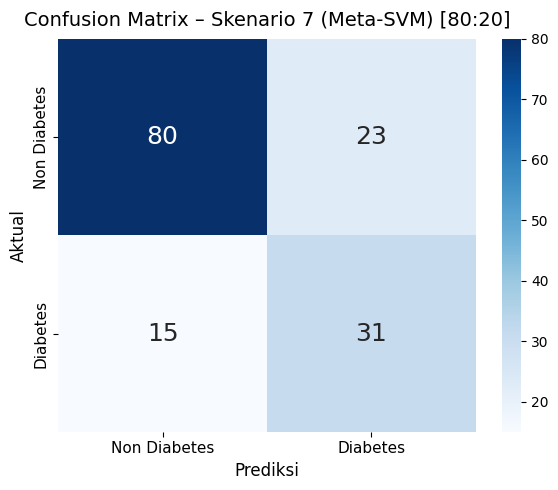

  Hasil Evaluasi Testing – Skenario 7 (Meta-SVM) [80:20]
  Akurasi  : 0.7450
  Presisi  : 0.5741
  Recall   : 0.6739
  F1-Score : 0.6200
waktu_predict_svm_meta_B: 28.88 ms


In [ ]:
svm_meta_final_B = grid_svm_meta_B.best_estimator_
import time
_t0 = time.time()
y_pred_svm_meta_B = svm_meta_final_B.predict(X_test_B)
waktu_predict_svm_meta_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_svm_meta_B, y_test_B, nama_skenario='Skenario 7 [80:20]')
plot_confusion_matrix('Skenario 7 (Meta-SVM) [80:20]', y_test_B, y_pred_svm_meta_B)
hasil_svm_meta_B = evaluasi_testing('Skenario 7 (Meta-SVM) [80:20]', y_test_B, y_pred_svm_meta_B)
print(f'waktu_predict_svm_meta_B: {waktu_predict_svm_meta_B:.2f} ms')

### Skenario 8 Stacking (Meta-ANN) [80:20]

In [ ]:
import time
_t0 = time.time()
stacking_ann_B = StackingClassifier(
    estimators=estimators_B,
    final_estimator=MLPClassifier(random_state=42),
    cv=kfold_B,
    stack_method='predict_proba',
    n_jobs=-1
)
grid_ann_meta_B = GridSearchCV(
    estimator=stacking_ann_B,
    param_grid=param_grid_ann,
    cv=kfold_B,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_ann_meta_B.fit(X_train_smote_B, y_train_smote_B)
print(f'ANN Meta Best Score (80:20): {grid_ann_meta_B.best_score_:.4f}')
print(f'ANN Meta Best Params: {grid_ann_meta_B.best_params_}')
results_ann_meta_B = pd.DataFrame(grid_ann_meta_B.cv_results_)
best_idx = grid_ann_meta_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_ann_meta_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_ann_meta_B.best_score_:.4f}')
waktu_train_ann_meta_B = (time.time() - _t0) * 1000
print(f'waktu_train_ann_meta_B: {waktu_train_ann_meta_B:.2f} ms')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
ANN Meta Best Score (80:20): 0.8003
ANN Meta Best Params: {'activation': 'logistic', 'hidden_layer_sizes': (20, 10), 'learning_rate_init': 0.001, 'max_iter': 100}
Fold 1: 0.7500
Fold 2: 0.8065
Fold 3: 0.8065
Fold 4: 0.8000
Fold 5: 0.8387
Mean: 0.8003
waktu_train_ann_meta_B: 146196.16 ms


,Prediksi Skenario 8 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,1,1,Tebakan Benar (True Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


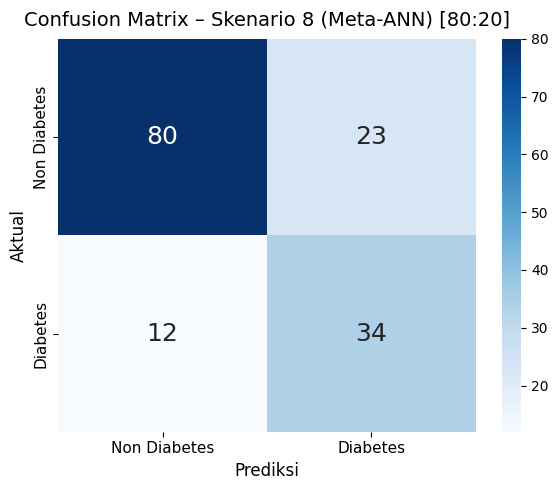

  Hasil Evaluasi Testing – Skenario 8 (Meta-ANN) [80:20]
  Akurasi  : 0.7651
  Presisi  : 0.5965
  Recall   : 0.7391
  F1-Score : 0.6602
waktu_predict_ann_meta_B: 1.18 ms


In [ ]:
ann_meta_final_B = grid_ann_meta_B.best_estimator_
import time
_t0 = time.time()
y_pred_ann_meta_B = ann_meta_final_B.predict(X_test_B)
waktu_predict_ann_meta_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_ann_meta_B, y_test_B, nama_skenario='Skenario 8 [80:20]')
plot_confusion_matrix('Skenario 8 (Meta-ANN) [80:20]', y_test_B, y_pred_ann_meta_B)
hasil_ann_meta_B = evaluasi_testing('Skenario 8 (Meta-ANN) [80:20]', y_test_B, y_pred_ann_meta_B)
print(f'waktu_predict_ann_meta_B: {waktu_predict_ann_meta_B:.2f} ms')

In [160]:
# === TABEL PERBANDINGAN SKENARIO 1-8 (SECTION B: 80:20) ===
hasil_semua_B = [
    hasil_knn_B, hasil_lr_B, hasil_svm_B, hasil_ann_B,
    hasil_knn_meta_B, hasil_lr_meta_B, hasil_svm_meta_B, hasil_ann_meta_B,
]
df_perbandingan_B = pd.DataFrame(hasil_semua_B)
df_perbandingan_B.insert(0, 'Pembagian Data', '80:20')
df_perbandingan_B.index = range(1, len(df_perbandingan_B) + 1)
df_perbandingan_B.index.name = 'No'
print('=== SECTION B (80:20) ===')
display(df_perbandingan_B)
print('\nModel Terbaik per Metrik (80:20):')
for metrik in ['Akurasi', 'Presisi', 'Recall', 'F1-Score']:
    best_idx = df_perbandingan_B[metrik].idxmax()
    best_model = df_perbandingan_B.loc[best_idx, 'Model']
    best_val   = df_perbandingan_B.loc[best_idx, metrik]
    print(f'  {metrik:10s}: {best_model} ({best_val:.4f})')

=== SECTION B (80:20) ===


,Pembagian Data,Model,Akurasi,Presisi,Recall,F1-Score
No,,,,,,
1,80:20,Skenario 1 (KNN) [80:20],0.6980,0.5070,0.7826,0.6154
2,80:20,Skenario 2 (LR) [80:20],0.7450,0.5606,0.8043,0.6607
3,80:20,Skenario 3 (SVM) [80:20],0.7047,0.5217,0.5217,0.5217
4,80:20,Skenario 4 (ANN) [80:20],0.7517,0.5789,0.7174,0.6408
5,80:20,Skenario 5 (Meta-KNN) [80:20],0.7450,0.5800,0.6304,0.6042
6,80:20,Skenario 6 (Meta-LR) [80:20],0.7517,0.5818,0.6957,0.6337
7,80:20,Skenario 7 (Meta-SVM) [80:20],0.7450,0.5741,0.6739,0.6200
8,80:20,Skenario 8 (Meta-ANN) [80:20],0.7651,0.5965,0.7391,0.6602



Model Terbaik per Metrik (80:20):
  Akurasi   : Skenario 8 (Meta-ANN) [80:20] (0.7651)
  Presisi   : Skenario 8 (Meta-ANN) [80:20] (0.5965)
  Recall    : Skenario 2 (LR) [80:20] (0.8043)
  F1-Score  : Skenario 2 (LR) [80:20] (0.6607)


---
# 📊 PERBANDINGAN AKHIR: SECTION A (70:30) vs SECTION B (80:20)

=== TABEL GABUNGAN SEMUA SKENARIO (A: 70:30 + B: 80:20) ===


,Pembagian Data,Model,Akurasi,Presisi,Recall,F1-Score
No,,,,,,
1,70:30,Skenario 1 (KNN),0.6830,0.5140,0.7432,0.6077
2,70:30,Skenario 2 (LR),0.6920,0.5214,0.8243,0.6387
3,70:30,Skenario 3 (SVM),0.7098,0.5506,0.6622,0.6012
4,70:30,Skenario 4 (ANN),0.7634,0.6082,0.7973,0.6901
5,70:30,Skenario 5 Stacking (Meta-KNN),0.7366,0.5904,0.6622,0.6242
6,70:30,Skenario 6 Stacking (Meta-lr),0.7366,0.5882,0.6757,0.6289
7,70:30,Skenario 7 Stacking (Meta-SVM),0.7321,0.5854,0.6486,0.6154
8,70:30,Skenario 8 Stacking (Meta-ANN),0.7321,0.5761,0.7162,0.6386
9,80:20,Skenario 1 (KNN) [80:20],0.6980,0.5070,0.7826,0.6154


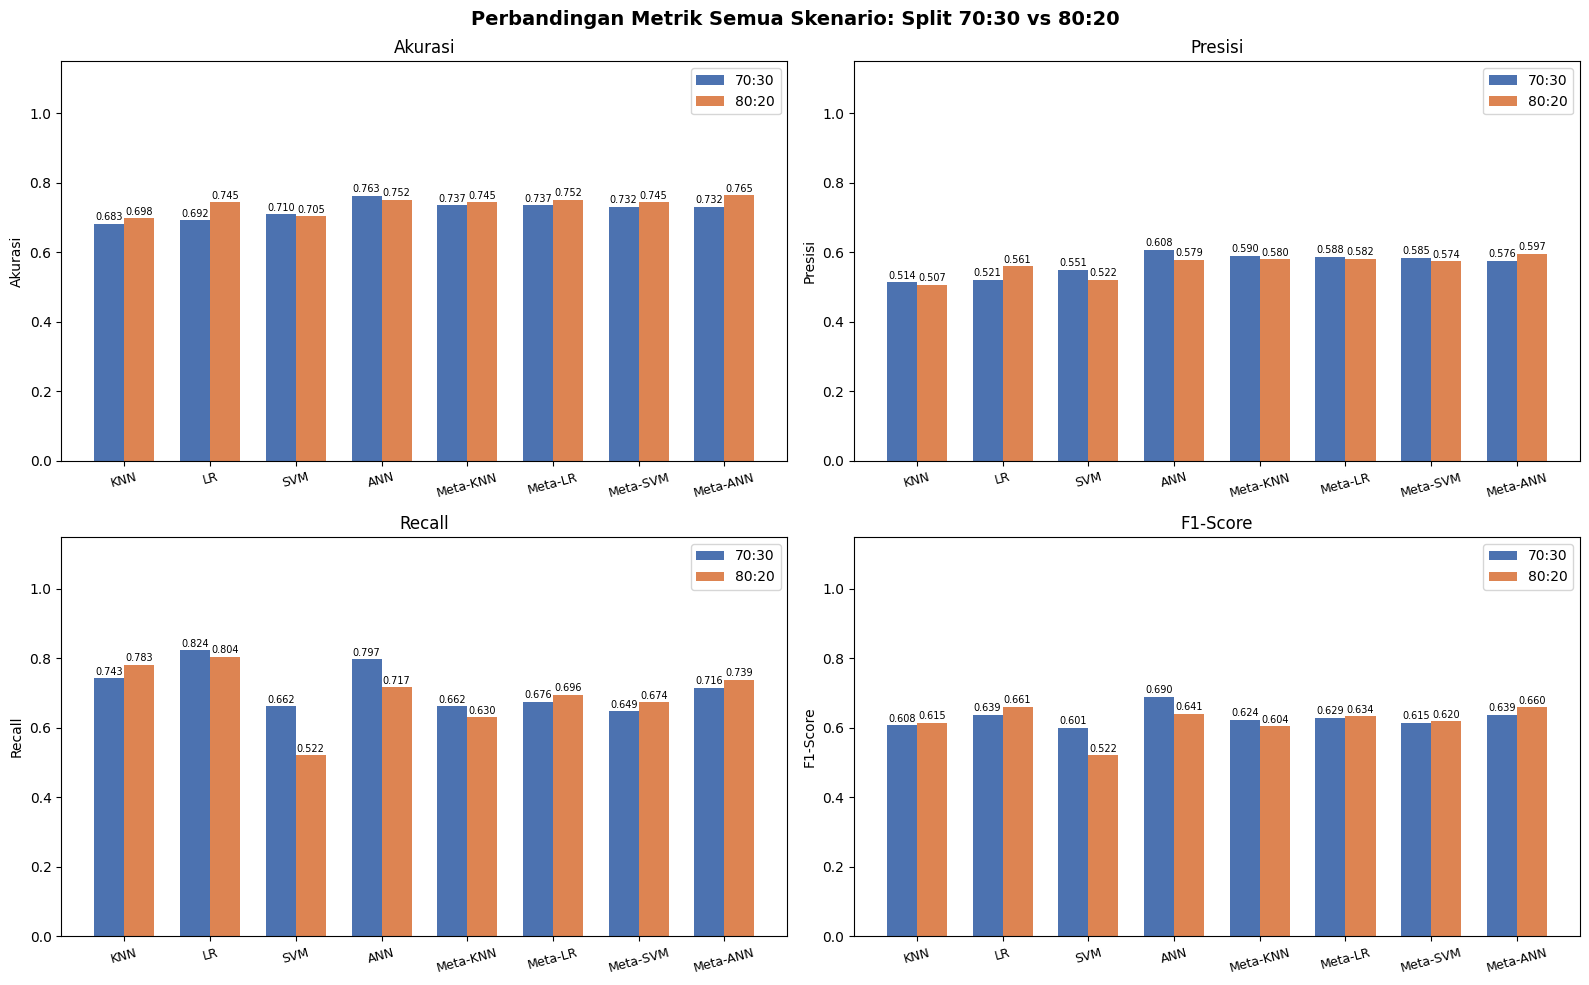


=== RINGKASAN MODEL TERBAIK PER METRIK ===
Metrik       | 70:30 (Model, Nilai)                | 80:20 (Model, Nilai)               
----------------------------------------------------------------------------------------
Akurasi      | Skenario 4 (ANN) (0.7634)           | Skenario 8 (Meta-ANN) [80:20] (0.7651)
Presisi      | Skenario 4 (ANN) (0.6082)           | Skenario 8 (Meta-ANN) [80:20] (0.5965)
Recall       | Skenario 2 (LR) (0.8243)            | Skenario 2 (LR) [80:20] (0.8043)   
F1-Score     | Skenario 4 (ANN) (0.6901)           | Skenario 2 (LR) [80:20] (0.6607)   

Tabel perbandingan tersimpan: perbandingan_split_70vs80.xlsx


In [161]:
# ============================================================
# PERBANDINGAN HASIL AKHIR: 70:30 vs 80:20
# ============================================================

# Gabungkan kedua tabel
df_semua = pd.concat([df_perbandingan_A, df_perbandingan_B], ignore_index=True)
df_semua.index = range(1, len(df_semua) + 1)
df_semua.index.name = 'No'
print('=== TABEL GABUNGAN SEMUA SKENARIO (A: 70:30 + B: 80:20) ===')
display(df_semua)

# --- Label bersih untuk visualisasi (tanpa suffix split) ---
import numpy as np
label_bersih = [
    'KNN', 'LR', 'SVM', 'ANN',
    'Meta-KNN', 'Meta-LR', 'Meta-SVM', 'Meta-ANN'
]
x = np.arange(len(label_bersih))
width = 0.35
metriks = ['Akurasi', 'Presisi', 'Recall', 'F1-Score']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, metrik in zip(axes.flatten(), metriks):
    vals_A = df_perbandingan_A[metrik].values
    vals_B = df_perbandingan_B[metrik].values
    bars_A = ax.bar(x - width/2, vals_A, width, label='70:30', color='#4C72B0')
    bars_B = ax.bar(x + width/2, vals_B, width, label='80:20', color='#DD8452')
    ax.set_title(metrik, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(label_bersih, fontsize=9, rotation=15)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(metrik)
    ax.legend()
    for bar in bars_A:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=7)
    for bar in bars_B:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=7)

plt.suptitle('Perbandingan Metrik Semua Skenario: Split 70:30 vs 80:20',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Ringkasan teks: model terbaik tiap split ---
print('\n=== RINGKASAN MODEL TERBAIK PER METRIK ===')
header = f'{"Metrik":12s} | {"70:30 (Model, Nilai)":35s} | {"80:20 (Model, Nilai)":35s}'
print(header)
print('-' * len(header))
for metrik in metriks:
    best_A = df_perbandingan_A.loc[df_perbandingan_A[metrik].idxmax()]
    best_B = df_perbandingan_B.loc[df_perbandingan_B[metrik].idxmax()]
    label_A = f"{best_A['Model']} ({best_A[metrik]:.4f})"
    label_B = f"{best_B['Model']} ({best_B[metrik]:.4f})"
    print(f'{metrik:12s} | {label_A:35s} | {label_B:35s}')

# --- Ekspor ke Excel ---
with pd.ExcelWriter('perbandingan_split_70vs80.xlsx', engine='openpyxl') as writer:
    df_perbandingan_A.to_excel(writer, sheet_name='70-30', index=True)
    df_perbandingan_B.to_excel(writer, sheet_name='80-20', index=True)
    df_semua.to_excel(writer, sheet_name='Gabungan', index=True)
print('\nTabel perbandingan tersimpan: perbandingan_split_70vs80.xlsx')

# EXPORT HASIL KOMBINASI PARAMETER

In [162]:
# import pandas as pd

# def cv_results_to_export(nama_model, results_df):
#     df = results_df[["params", "mean_test_score", "rank_test_score"]].copy()
#     df = df.dropna(subset=["mean_test_score"])

#     df.rename(columns={
#         "params": "Kombinasi Parameter",
#         "mean_test_score": "Rata Rata",
#         "rank_test_score": "Peringkat",
#     }, inplace=True)

#     df.insert(0, "Nama Model", nama_model)
#     df["Kombinasi Parameter"] = df["Kombinasi Parameter"].astype(str)
#     return df

# # =========================
# # BASE (sheet 1)
# # =========================
# df_base = pd.concat([
#     cv_results_to_export("KNN", results_knn),
#     cv_results_to_export("LogReg", results_lr),
#     cv_results_to_export("SVM", results_svm),
#     cv_results_to_export("ANN", results_ann),
# ], ignore_index=True)

# df_base = df_base.sort_values(["Nama Model", "Peringkat"], ascending=[True, True]).reset_index(drop=True)
# df_base.insert(0, "No", range(1, len(df_base) + 1))

# # =========================
# # META (sheet 2)
# # =========================
# df_meta = pd.concat([
#     cv_results_to_export("KNN", results_knn_meta),
#     cv_results_to_export("LogReg", results_logreg_meta),
#     cv_results_to_export("SVM", results_svm_meta),
#     cv_results_to_export("ANN", results_ann_meta),
# ], ignore_index=True)

# df_meta = df_meta.sort_values(["Nama Model", "Peringkat"], ascending=[True, True]).reset_index(drop=True)
# df_meta.insert(0, "No", range(1, len(df_meta) + 1))

# # =========================
# # EXPORT (2 sheet)
# # =========================
# output_excel = "rekap_kombinasi_parameter_base_dan_meta.xlsx"
# with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
#     df_base.to_excel(writer, index=False, sheet_name="Base")
#     df_meta.to_excel(writer, index=False, sheet_name="Meta")

# print("Berhasil membuat:", output_excel)
# print("Total baris Base:", len(df_base))
# print("Total baris Meta:", len(df_meta))

# OUTPUT PELATIHAN MODEL

### KNN

In [163]:
# print(f"Metrik Jarak: {knn_final.effective_metric_}")
# print(f"Jumlah Sampel Latihan: {knn_final.n_samples_fit_}")

## LR

In [164]:
# print(f"Koefisien (Bobot): \n{lr_final.coef_}")
# print(f"Intercept (Bias): {lr_final.intercept_}")
# print(f"Jumlah Iterasi: {lr_final.n_iter_}")

## SVM

In [165]:
# print(f"Indeks Support Vectors: {svm_final.support_}")
# print(f"Jumlah Support Vectors per kelas: {svm_final.n_support_[0]} (kelas 0), {svm_final.n_support_[1]} (kelas 1)")
# print(f"Konstanta Bias (intercept_): {svm_final.intercept_}")
# print(f"Total Support Vectors: {sum(svm_final.n_support_)}")

In [166]:
# n_fitur = X_train_smote.shape[1]
# gamma_auto = 1 / n_fitur
# print(gamma_auto)

In [167]:
# X_var = X_train_smote.to_numpy().var()
# print(X_var)
# gamma_scale = 1/(n_fitur * X_var)
# print(f"Gamma Scale: {gamma_scale:.4f}")

## ANN

In [168]:
# # Hasil pelatihan ANN
# print(ann_final.loss_)
# print(ann_final.n_iter_)
# print(ann_final.t_)
# print(ann_final.n_layers_)
# print(ann_final.n_outputs_)
# print(ann_final.out_activation_)
# print(f"\nShape Matriks Bobot (coefs_): {[c.shape for c in ann_final.coefs_]}")
# print(f"Shape Vektor Bias (intercepts_): {[i.shape for i in ann_final.intercepts_]}")

In [169]:
# import matplotlib.pyplot as plt

# # 1. Mengambil data loss_curve_ dari model yang sudah dilatih
# loss_values = ann_final.loss_curve_

# # 2. Membuat plot
# plt.figure(figsize=(10, 6))
# plt.plot(loss_values, label='Loss (Error)', color='tab:orange', linewidth=2)

# # 3. Menambahkan label dan judul untuk kebutuhan Skripsi
# plt.title('Grafik Konvergensi Loss (Epoch) Skenario 4', fontsize=14)
# plt.xlabel('Iterasi (Epoch)', fontsize=12)
# plt.ylabel('Nilai Loss', fontsize=12)

# # 4. Menandai titik akhir (konvergensi)
# plt.scatter(len(loss_values)-1, loss_values[-1], color='red')
# plt.text(len(loss_values)-1, loss_values[-1], f' Loss Akhir: {loss_values[-1]:.4f}',
#          verticalalignment='bottom', horizontalalignment='right')

# # 5. Mempercantik tampilan
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.legend()
# plt.show()

## KNN-META

In [170]:
# print(f"Metrik Jarak: {knn_meta_final.effective_metric_}")
# print(f"Jumlah Sampel Latihan: {knn_meta_final.n_samples_fit_}")

## LR-META

In [171]:
# print(f"Koefisien (Bobot): \n{logreg_meta_final.coef_}")
# print(f"Intercept (Bias): {logreg_meta_final.intercept_}")
# print(f"Jumlah Iterasi: {logreg_meta_final.n_iter_}")

## SVM-META

In [172]:
# print(f"Indeks Support Vectors: {svm_meta_final.support_}")
# print(f"Jumlah Support Vectors per kelas: {svm_meta_final.n_support_}")
# print(f"Konstanta Bias (intercept_): {svm_meta_final.intercept_}")

In [173]:
# n_fitur = X_meta_latih.shape[1]
# gamma_auto = 1 / n_fitur
# print(gamma_auto)

In [174]:
# X_var = X_meta_latih.to_numpy().var()
# print(X_var)
# gamma_scale = 1/(n_fitur * X_var)
# print(f"Gamma Scale: {gamma_scale:.4f}")

## ANN-META

In [175]:
# # Hasil pelatihan ANN
# print(ann_meta_final.loss_)
# print(ann_meta_final.n_iter_)
# print(ann_meta_final.t_)
# print(ann_meta_final.n_layers_)
# print(ann_meta_final.n_outputs_)
# print(ann_meta_final.out_activation_)
# print(f"\nShape Matriks Bobot (coefs_): {[c.shape for c in ann_meta_final.coefs_]}")
# print(f"Shape Vektor Bias (intercepts_): {[i.shape for i in ann_meta_final.intercepts_]}")

In [176]:
# import matplotlib.pyplot as plt

# # 1. Mengambil data loss_curve_ dari model yang sudah dilatih
# loss_values = ann_meta_final.loss_curve_

# # 2. Membuat plot
# plt.figure(figsize=(10, 6))
# plt.plot(loss_values, label='Loss (Error)', color='tab:orange', linewidth=2)

# # 3. Menambahkan label dan judul untuk kebutuhan Skripsi
# plt.title('Grafik Konvergensi Loss (Epoch) Skenario 8', fontsize=14)
# plt.xlabel('Iterasi (Epoch)', fontsize=12)
# plt.ylabel('Nilai Loss', fontsize=12)

# # 4. Menandai titik akhir (konvergensi)
# plt.scatter(len(loss_values)-1, loss_values[-1], color='red')
# plt.text(len(loss_values)-1, loss_values[-1], f' Loss Akhir: {loss_values[-1]:.4f}',
#          verticalalignment='bottom', horizontalalignment='right')

# # 5. Mempercantik tampilan
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.legend()
# plt.show()

# SIMPAN MODEL UNTUK DEPLOYMENT

In [177]:
# import numpy as np

# def ekstrak_info_grid(nama_model, grid_obj, kfold_obj):
#     """
#     Ekstrak info GridSearchCV secara dinamis.
#     Tidak ada hardcode — semua diambil dari objek hasil fit.
#     """
#     results_df = pd.DataFrame(grid_obj.cv_results_)
#     best_idx   = grid_obj.best_index_
#     n_splits   = kfold_obj.get_n_splits()

#     fold_scores = [
#         float(results_df.loc[best_idx, f"split{k}_test_score"])
#         for k in range(n_splits)
#     ]

#     # Konversi best_params agar JSON-serializable (np.float64 → float, tuple → list)
#     def to_json_safe(v):
#         if isinstance(v, (np.integer,)):  return int(v)
#         if isinstance(v, (np.floating,)): return float(v)
#         if isinstance(v, tuple):          return list(v)
#         return v

#     best_params_safe = {k: to_json_safe(v) for k, v in grid_obj.best_params_.items()}

#     return {
#         "model"      : nama_model,
#         "cv"         : {
#             "n_folds"     : n_splits,
#             "n_candidates": len(results_df),
#             "total_fits"  : n_splits * len(results_df),
#         },
#         "best_score" : round(float(grid_obj.best_score_), 4),
#         "best_params": best_params_safe,
#         "fold_scores": [round(s, 4) for s in fold_scores],
#         "mean"       : round(float(grid_obj.best_score_), 4),
#     }


# def simpan_model_dan_info(nama_file, nama_model, model_obj, grid_obj, kfold_obj, out_dir):
#     """
#     Simpan model (.joblib) + info (.json) secara dinamis.
#     nama_file : prefix file, misal 'knn' → knn_model.joblib & knn_info.json
#     """
#     out_dir = Path(out_dir)
#     out_dir.mkdir(parents=True, exist_ok=True)

#     # Simpan model
#     joblib.dump(model_obj, out_dir / f"{nama_file}_model.joblib")

#     # Buat & simpan info
#     info = ekstrak_info_grid(nama_model, grid_obj, kfold_obj)
#     with open(out_dir / f"{nama_file}_info.json", "w", encoding="utf-8") as f:
#         json.dump(info, f, indent=2, ensure_ascii=False)

#     print(f"[OK] {nama_file}_model.joblib & {nama_file}_info.json tersimpan")
#     return info

# print("Fungsi simpan_model_dan_info siap digunakan.")

## Simpan Semua Model Base Learner

In [178]:
# out_dir = "for_deployment"

# knn_info      = simpan_model_dan_info("knn",  "KNN",               knn_final,         grid_knn,        kfold, out_dir)
# lr_info       = simpan_model_dan_info("lr",   "LogisticRegression", lr_final,          grid_lr,         kfold, out_dir)
# svm_info      = simpan_model_dan_info("svm",  "SVM",               svm_final,         grid_svm,        kfold, out_dir)
# ann_info      = simpan_model_dan_info("ann",  "ANN",               ann_final,         grid_ann,        kfold, out_dir)

## Simpan Semua Model Meta Learner

In [179]:
# knn_meta_info  = simpan_model_dan_info("knn_meta",    "KNN_META",     knn_meta_final,    grid_knn_meta,    kfold, out_dir)
# lr_meta_info   = simpan_model_dan_info("logreg_meta", "LogReg_META",  logreg_meta_final, grid_logreg_meta, kfold, out_dir)
# svm_meta_info  = simpan_model_dan_info("svm_meta",    "SVM_META",     svm_meta_final,    grid_svm_meta,    kfold, out_dir)
# ann_meta_info  = simpan_model_dan_info("ann_meta",    "ANN_META",     ann_meta_final,    grid_ann_meta,    kfold, out_dir)

# PERBANDINGAN WAKTU KOMPUTASI ANTAR SKENARIO

In [180]:
# # Waktu training stacking = waktu buat dataset_training_meta + waktu fit meta learner
# # Waktu predict stacking   = waktu buat dataset_testing_meta  + waktu predict meta learner

# data_waktu = [
#     {
#         "Skenario"         : "Skenario 1 (KNN)",
#         "Waktu Training (ms)": round(waktu_train_knn, 2),
#         "Waktu Prediksi (ms)": round(waktu_predict_knn, 2),
#     },
#     {
#         "Skenario"         : "Skenario 2 (LR)",
#         "Waktu Training (ms)": round(waktu_train_lr, 2),
#         "Waktu Prediksi (ms)": round(waktu_predict_lr, 2),
#     },
#     {
#         "Skenario"         : "Skenario 3 (SVM)",
#         "Waktu Training (ms)": round(waktu_train_svm, 2),
#         "Waktu Prediksi (ms)": round(waktu_predict_svm, 2),
#     },
#     {
#         "Skenario"         : "Skenario 4 (ANN)",
#         "Waktu Training (ms)": round(waktu_train_ann, 2),
#         "Waktu Prediksi (ms)": round(waktu_predict_ann, 2),
#     },
#     {
#         "Skenario"         : "Skenario 5 Stacking (Meta-KNN)",
#         # training  = pengumpulan dataset training meta + fit meta learner
#         "Waktu Training (ms)": round(waktu_buat_dataset_training_meta + waktu_train_knn_meta, 2),
#         # prediksi  = pengumpulan dataset testing meta + predict meta learner
#         "Waktu Prediksi (ms)": round(waktu_buat_dataset_testing_meta  + waktu_predict_knn_meta, 2),
#     },
#     {
#         "Skenario"         : "Skenario 6 Stacking (Meta-LR)",
#         "Waktu Training (ms)": round(waktu_buat_dataset_training_meta + waktu_train_lr_meta, 2),
#         "Waktu Prediksi (ms)": round(waktu_buat_dataset_testing_meta  + waktu_predict_lr_meta, 2),
#     },
#     {
#         "Skenario"         : "Skenario 7 Stacking (Meta-SVM)",
#         "Waktu Training (ms)": round(waktu_buat_dataset_training_meta + waktu_train_svm_meta, 2),
#         "Waktu Prediksi (ms)": round(waktu_buat_dataset_testing_meta  + waktu_predict_svm_meta, 2),
#     },
#     {
#         "Skenario"         : "Skenario 8 Stacking (Meta-ANN)",
#         "Waktu Training (ms)": round(waktu_buat_dataset_training_meta + waktu_train_ann_meta, 2),
#         "Waktu Prediksi (ms)": round(waktu_buat_dataset_testing_meta  + waktu_predict_ann_meta, 2),
#     },
# ]

# df_waktu = pd.DataFrame(data_waktu)
# df_waktu

In [181]:
# # Visualisasi perbandingan waktu komputasi
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# warna = [
#     "#4C72B0", "#4C72B0", "#4C72B0", "#4C72B0",  # base learner — biru
#     "#DD8452", "#DD8452", "#DD8452", "#DD8452",  # stacking — oranye
# ]
# skenario_labels = [s.replace("Skenario ", "S").replace(" Stacking", "\nStacking") for s in df_waktu["Skenario"]]

# # Waktu Training
# axes[0].bar(skenario_labels, df_waktu["Waktu Training (ms)"], color=warna)
# axes[0].set_title("Waktu Training per Skenario", fontsize=13)
# axes[0].set_ylabel("Waktu (ms)")
# axes[0].set_xlabel("Skenario")
# axes[0].tick_params(axis="x", labelsize=8)
# for i, v in enumerate(df_waktu["Waktu Training (ms)"]):
#     axes[0].text(i, v + 0.5, f"{v:.0f}", ha="center", fontsize=7)

# # Waktu Prediksi
# axes[1].bar(skenario_labels, df_waktu["Waktu Prediksi (ms)"], color=warna)
# axes[1].set_title("Waktu Prediksi per Skenario", fontsize=13)
# axes[1].set_ylabel("Waktu (ms)")
# axes[1].set_xlabel("Skenario")
# axes[1].tick_params(axis="x", labelsize=8)
# for i, v in enumerate(df_waktu["Waktu Prediksi (ms)"]):
#     axes[1].text(i, v + 0.1, f"{v:.2f}", ha="center", fontsize=7)

# # Legend manual
# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor="#4C72B0", label="Base Learner"),
#                    Patch(facecolor="#DD8452", label="Stacking")]
# fig.legend(handles=legend_elements, loc="upper right", fontsize=10)

# plt.suptitle("Perbandingan Waktu Komputasi Antar Skenario", fontsize=14, fontweight="bold")
# plt.tight_layout()
# plt.show()

In [182]:
# # Ekspor tabel waktu komputasi ke Excel
# df_waktu.to_excel("waktu_komputasi_skenario.xlsx", index=False)
# print("Tabel waktu komputasi tersimpan: waktu_komputasi_skenario.xlsx")

## Bedah Model

### KNN S1

In [183]:
# import numpy as np
# import pandas as pd
# from IPython.display import display

# # 1. Hitung jarak dan probabilitas untuk seluruh data testing
# distances_all, indices_all = knn_final.kneighbors(X_test)
# prob_all = knn_final.predict_proba(X_test)[:, 1]

# # 2. Filter data secara ketat
# valid_indices = []
# for i in range(len(distances_all)):
#     dists = distances_all[i]
#     prob = prob_all[i]

#     # Syarat 1: Probabilitas BUKAN 0.0 dan BUKAN 1.0 (Harus ada campuran kelas tetangga)
#     if prob == 0.0 or prob == 1.0:
#         continue

#     # Syarat 2: Jarak pertama tidak boleh 0.0000
#     if dists[0] == 0:
#         continue

#     # Syarat 3: Jarak harus bervariasi (minimal 4 jarak berbeda dari 5 tetangga)
#     unique_dists = np.unique(dists)
#     if len(unique_dists) >= 4:
#         valid_indices.append(i)

# valid_indices = np.array(valid_indices)

# # 3. Ambil 5 sampel acak dari daftar yang sudah difilter
# if len(valid_indices) < 5:
#     print(f"Catatan: Hanya ditemukan {len(valid_indices)} data yang memenuhi syarat ketat ini.")
#     sample_idx = valid_indices
# else:
#     np.random.seed(42) # Angka seed agar hasilnya tetap sama jika di-run ulang
#     sample_idx = np.random.choice(valid_indices, 5, replace=False)

# # 4. Ambil data sampel berdasarkan indeks yang terpilih
# X_sample = X_test.values[sample_idx] if hasattr(X_test, 'values') else X_test[sample_idx]
# y_sample_asli = y_test.values[sample_idx] if hasattr(y_test, 'values') else y_test[sample_idx]
# index_sample = y_test.index[sample_idx] if hasattr(y_test, 'index') else sample_idx

# # 5. Dapatkan jarak dan indeks 5 tetangga terdekat khusus
# distances = distances_all[sample_idx]
# indices = indices_all[sample_idx]

# # 6. Dapatkan probabilitas (Kelas 0 dan 1) dan prediksi akhir
# prob_library = knn_final.predict_proba(X_sample)
# pred_library = knn_final.predict(X_sample)

# # 7. Ambil label asli dari data training untuk mengetahui kelas tetangga
# y_train_array = y_train_smote.values if hasattr(y_train_smote, 'values') else y_train_smote

# # 8. Susun data menjadi DataFrame
# data_tabel = []
# for i in range(len(X_sample)):
#     row_data = {
#         # 'Urutan di Data Uji': sample_idx[i],
#         # 'Index': index_sample[i]
#     }

#     # Memasukkan jarak dan kelas untuk masing-masing ke-5 tetangga
#     for k in range(5):
#         dist = distances[i][k]
#         kelas_tetangga = y_train_array[indices[i][k]]
#         row_data[f'Tetangga {k+1}'] = f"{dist:.4f} (K:{kelas_tetangga})"

#     # Memasukkan hasil probabilitas Kelas 0, Kelas 1, dan Prediksi
#     # row_data['Probabilitas Kelas 0'] = round(prob_library[i][0], 5)
#     # row_data['Probabilitas Kelas 1'] = round(prob_library[i][1], 5)
#     row_data['Prediksi Model'] = pred_library[i]
#     row_data['Label Asli'] = y_sample_asli[i]

#     data_tabel.append(row_data)

# df_knn_sempurna = pd.DataFrame(data_tabel)

# print("--- DETAIL JARAK TETANGGA (VARIAN JARAK & PROBABILITAS CAMPURAN) ---")
# display(df_knn_sempurna)

### LR S2

In [184]:
# import numpy as np
# import pandas as pd
# from IPython.display import display

# # 1. Pastikan data testing berbentuk matriks angka
# X_test_array = X_test.values if hasattr(X_test, 'values') else X_test

# # 2. Ambil koefisien (w) dan intercept (b)
# w = lr_final.coef_[0]
# b = lr_final.intercept_[0]

# # 3. KALKULASI MATEMATIS MANUAL
# # Hitung kombinasi linear (z) = w*x + b
# z_manual = np.dot(X_test_array, w) + b

# # Hitung f(x) menggunakan rumus Sigmoid
# fx_manual = 1 / (1 + np.exp(-z_manual))

# # Probabilitas Kelas 1 dan Kelas 0
# p_manual_1 = fx_manual
# p_manual_0 = 1 - p_manual_1

# # 4. KEPUTUSAN PREDIKSI (Berdasarkan teori ambang batas > 0.5)
# # Jika fx_manual >= 0.5, maka hasilnya 1. Jika tidak, hasilnya 0.
# prediksi_manual = (fx_manual >= 0.5).astype(int)

# # 5. SUSUN TABEL MANUAL
# df_manual = pd.DataFrame({

#     'Hasil z': z_manual.round(5),
#     'Hasil f(x)': fx_manual.round(5),
#     'Prediksi Model': prediksi_manual,
#     'Label Asli': y_test.values if hasattr(y_test, 'values') else y_test,
# })

# print("--- BUKTI PERHITUNGAN MATEMATIS MANUAL ---")
# display(df_manual.head(5))

### SVM S3

In [185]:
# import numpy as np
# import pandas as pd
# from IPython.display import display

# # 1. Pastikan data berformat array
# X_test_array = X_test.values if hasattr(X_test, 'values') else X_test

# # 2. Ekstrak parameter matematis dari model SVM RBF Anda
# SVs = svm_final.support_vectors_       # Koordinat titik Support Vectors
# dual_coefs = svm_final.dual_coef_[0]   # Koefisien dual (Alpha * y)
# b = svm_final.intercept_[0]            # Nilai bias (konstanta)
# gamma = svm_final._gamma            # Nilai gamma dari kernel RBF

# # 3. KALKULASI MATEMATIS FUNGSI KEPUTUSAN UNTUK SELURUH DATA TESTING
# fx_list = []
# prediksi_list = []

# for sample_x in X_test_array:
#     # a. Hitung kuadrat jarak (Euclidean) ke semua Support Vectors
#     sq_distances = np.sum((SVs - sample_x) ** 2, axis=1)

#     # b. Fungsi Kernel RBF
#     K = np.exp(-gamma * sq_distances)

#     # c. Fungsi Keputusan f(x)
#     fx = np.dot(dual_coefs, K) + b
#     fx_list.append(fx)

#     # d. Aturan Keputusan SVM (Threshold 0)
#     prediksi = 1 if fx >= 0 else 0
#     prediksi_list.append(prediksi)

# # 4. SUSUN TABEL HASIL MATEMATIS
# df_matematis = pd.DataFrame({
#     'f(x)': np.round(fx_list, 5),
#     'Prediksi Model': prediksi_list,
#     'Label Asli': y_test.values if hasattr(y_test, 'values') else y_test,
# })

# print("--- HASIL PERHITUNGAN MATEMATIS FUNGSI KEPUTUSAN SVM ---")
# display(df_matematis.head(5))

### ANN S4

In [186]:

# from IPython.display import display

# # 1. Pastikan data berformat array
# X_test_array = X_test.values if hasattr(X_test, 'values') else X_test

# # 2. Ekstrak matriks bobot (W) dan bias (b) dari model ANN
# W1, W2, W3 = ann_final.coefs_
# b1, b2, b3 = ann_final.intercepts_

# # 3. PROSES FORWARD PROPAGATION MANUAL
# # --- Langkah 1: Input ke Hidden Layer 1 ---
# # Z1 = (X * W1) + b1
# Z1 = np.dot(X_test_array, W1) + b1
# # Fungsi Aktivasi ReLU: max(0, Z)
# A1 = np.maximum(0, Z1)

# # --- Langkah 2: Hidden Layer 1 ke Hidden Layer 2 ---
# # Z2 = (A1 * W2) + b2
# Z2 = np.dot(A1, W2) + b2
# # Fungsi Aktivasi ReLU
# A2 = np.maximum(0, Z2)

# # --- Langkah 3: Hidden Layer 2 ke Output Layer ---
# # Z3 = (A2 * W3) + b3
# Z3 = np.dot(A2, W3) + b3
# # Karena matriks hasil ukurannya (N, 1), kita ratakan (flatten) jadi 1 dimensi
# Z3 = Z3.flatten()

# # Fungsi Aktivasi Output: Logistic (Sigmoid)
# p_manual_1 = 1 / (1 + np.exp(-Z3))
# p_manual_0 = 1 - p_manual_1



# # 5. SUSUN TABEL KOMPARASI
# df_ann_komparasi = pd.DataFrame({
#     'Probabilitas Kelas 1 (Manual Forward Prop)': p_manual_1.round(6),
# })


# display(df_ann_komparasi.head(15))

### META-KNN S5

In [187]:
# import numpy as np
# import pandas as pd
# from IPython.display import display

# # 1. Hitung jarak dan indeks untuk seluruh data meta-features uji
# distances_all, indices_all = knn_meta_final.kneighbors(X_meta_uji)
# pred_all = knn_meta_final.predict(X_meta_uji)
# y_train_meta_array = y_meta_latih.values if hasattr(y_meta_latih, 'values') else y_meta_latih

# # 2. Filter khusus: Cari data yang komposisi 13 tetangganya BERCAMPUR (Heterogen)
# valid_indices = []
# for i in range(len(distances_all)):
#     inds = indices_all[i]
#     kelas_tetangga = y_train_meta_array[inds]

#     # Menghitung berapa banyak Kelas 0 dan Kelas 1 di antara 13 tetangga
#     count_k0 = np.sum(kelas_tetangga == 0)
#     count_k1 = np.sum(kelas_tetangga == 1)

#     # Syarat Campuran: Minimal ada 3 tetangga dari kelas yang berbeda (tidak boleh 13-0 atau 12-1)
#     if count_k0 >= 3 and count_k1 >= 3:
#         # Syarat tambahan: Jarak tidak boleh nol (bukan duplikat)
#         if distances_all[i][0] > 0:
#             valid_indices.append(i)

# valid_indices = np.array(valid_indices)

# # 3. Ambil 5 sampel dari hasil filter
# if len(valid_indices) < 5:
#     print(f"Hanya ditemukan {len(valid_indices)} data dengan tetangga campuran. Mengambil semua yang ada.")
#     sample_idx = valid_indices
# else:
#     np.random.seed(10) # Seed diubah agar mendapat variasi baru
#     sample_idx = np.random.choice(valid_indices, 5, replace=False)

# # 4. Susun data secara vertikal
# y_sample_asli = y_meta_uji.values[sample_idx] if hasattr(y_meta_uji, 'values') else y_meta_uji[sample_idx]
# data_tabel = {}

# for i in range(len(sample_idx)):
#     col_name = f"Data uji {i+1}"
#     row_values = []

#     dists = distances_all[sample_idx[i]]
#     inds = indices_all[sample_idx[i]]

#     for k in range(11):
#         row_values.append(f"{dists[k]:.4f} (K:{y_train_meta_array[inds[k]]})")

#     row_values.append(int(pred_all[sample_idx[i]]))
#     row_values.append(int(y_sample_asli[i]))

#     data_tabel[col_name] = row_values

# indeks_baris = [f"Tetangga {i+1}" for i in range(11)] + ["PREDIKSI META", "LABEL ASLI"]
# df_vertikal = pd.DataFrame(data_tabel, index=indeks_baris)

# print("--- DETAIL 13 TETANGGA (KOMPOSISI CAMPURAN/HETEROGEN) ---")
# display(df_vertikal)

### META-LR S6

In [188]:
# import numpy as np
# import pandas as pd
# from IPython.display import display

# # 1. Pastikan data testing berbentuk matriks angka
# X_test_array = X_meta_uji.values if hasattr(X_meta_uji, 'values') else X_meta_uji

# # 2. Ambil koefisien (w) dan intercept (b)
# w = logreg_meta_final.coef_[0]
# b = logreg_meta_final.intercept_[0]

# # 3. KALKULASI MATEMATIS MANUAL
# # Hitung kombinasi linear (z) = w*x + b
# z_manual = np.dot(X_test_array, w) + b

# # Hitung f(x) menggunakan rumus Sigmoid
# fx_manual = 1 / (1 + np.exp(-z_manual))

# # Probabilitas Kelas 1 dan Kelas 0
# p_manual_1 = fx_manual
# p_manual_0 = 1 - p_manual_1

# # 4. KEPUTUSAN PREDIKSI (Berdasarkan teori ambang batas > 0.5)
# # Jika fx_manual >= 0.5, maka hasilnya 1. Jika tidak, hasilnya 0.
# prediksi_manual = (fx_manual >= 0.5).astype(int)

# # 5. SUSUN TABEL MANUAL
# df_manual = pd.DataFrame({
#     'Hasil z': z_manual.round(5),
#     'Hasil f(x)': fx_manual.round(5),
#     'Prediksi Model': prediksi_manual,
#     'Label Asli': y_test.values if hasattr(y_test, 'values') else y_test,
# })

# print("--- BUKTI PERHITUNGAN MATEMATIS MANUAL ---")
# display(df_manual.head(5))

### META-SVM S7

In [189]:
# import numpy as np
# import pandas as pd
# from IPython.display import display

# # 1. Pastikan data berformat array (menggunakan meta-features uji)
# X_meta_uji_array = X_meta_uji.values if hasattr(X_meta_uji, 'values') else X_meta_uji

# # 2. Ekstrak parameter matematis dari model SVM Linear
# # meta_svm_final adalah nama variabel model SVM Stacking Anda
# w = svm_meta_final.coef_[0]      # Koefisien bobot fitur meta
# b = svm_meta_final.intercept_[0] # Nilai bias

# # 3. KALKULASI MATEMATIS FUNGSI KEPUTUSAN (Linear: f(x) = Xw + b)
# # Kita bisa menggunakan np.dot untuk perkalian matriks yang lebih cepat
# fx_list = np.dot(X_meta_uji_array, w) + b

# # 4. Aturan Keputusan (Threshold 0)
# prediksi_list = [1 if fx >= 0 else 0 for fx in fx_list]

# # 5. SUSUN TABEL HASIL MATEMATIS
# df_matematis_svm = pd.DataFrame({
#     'Nilai Jarak f(x)': np.round(fx_list, 5),
#     'Prediksi Model': prediksi_list,
#     'Label Asli': y_meta_uji.values if hasattr(y_meta_uji, 'values') else y_meta_uji
# })

# print("--- HASIL PERHITUNGAN MATEMATIS FUNGSI KEPUTUSAN META-SVM (LINEAR) ---")
# display(df_matematis_svm.head(15))

### ANN-META S8

In [190]:
# import pandas as pd
# import numpy as np
# from IPython.display import display

# # 1. Menentukan jumlah data testing yang tersedia
# n_total = len(X_meta_uji)

# # 2. Mengambil 5 nomor urut posisi secara acak (misal: urutan ke-10, ke-50, dst)
# np.random.seed(42) # Agar hasil acak tetap sama setiap kali dijalankan
# random_pos = np.random.choice(n_total, 5, replace=False)

# # 3. Mengambil data berdasarkan POSISI (iloc), bukan berdasarkan LABEL indeks
# # Ini akan menghindari KeyError
# X_meta_sample = X_meta_uji.iloc[random_pos]
# y_sample_asli = y_meta_uji.iloc[random_pos]

# # 4. Mendapatkan probabilitas dan prediksi dari model
# prob_meta_ann = ann_meta_final.predict_proba(X_meta_sample)
# pred_meta_ann = ann_meta_final.predict(X_meta_sample)

# # 5. Menyusun ke dalam DataFrame untuk Tabel Skripsi
# df_meta_ann_output = pd.DataFrame({
#     'Hasil Output Layer': prob_meta_ann[:, 1].round(5),
#     'Prediksi Model': pred_meta_ann,
#     'Label Asli': y_sample_asli.values
# })

# # 6. Reset indeks agar tampil rapi 0-4
# df_meta_ann_output = df_meta_ann_output.reset_index(drop=True)

# print("--- 5 SAMPEL DATA TESTING (PROSES POSISI ILOC) ---")
# display(df_meta_ann_output)